In [1]:
import pandas as pd

df = pd.read_csv("nepali_house_dataset.csv")

print(df.shape)

(3418, 13)


In [2]:
df.head()

,TITLE,LOCATION,PRICE,LAND AREA,BUILDUP AREA,ROAD ACCESS,FACING,FLOOR,BEDROOM,BATHROOM,BUILT YEAR,PARKING,AMENITIES
0,House for Sale,"Imadol, Lalitpur",Rs. 2.9 Cr,4.0 aana,NaN,12 Feet,West,3.0,5.0,4.0,2076 B.S,1 CaRs. & 2 Bikes,"['Earthquake Resistant', 'Marbel', 'Parquet', ..."
1,House for Sale,"Satdobato, Lalitpur",Rs. 4.75 Cr,3.0 aana,NaN,10 Feet,West,4.5,5.0,6.0,2076 B.S,2 CaRs. & 2 Bikes,"['Earthquake Resistant', 'Parquet', 'Drinking ..."
2,4 BHK House for Sale,"Imadol, Lalitpur",Rs. 1.99 Cr,2.3 aana,NaN,10 Feet,West,2.5,4.0,4.0,2060 B.S,1 CaRs. & 3 Bikes,"['Earthquake Resistant', 'Marbel', 'Parquet', ..."
3,Bungalow House for Sale,"Bhaisepati, Lalitpur",Rs. 4 Cr,7.0 aana,NaN,12 Feet,North-West,2.5,4.0,3.0,2059 B.S,4 CaRs. & 4 Bikes,"['Earthquake Resistant', 'Marbel', 'Parquet', ..."
4,House for Rent,"Maharajgunj, Kathmandu",Rs. 12000000,6.0 aana,NaN,20 Feet,South,2.0,4.0,4.0,2071 B.S,4 CaRs. & 5 Bikes,"['Earthquake Resistant', 'Parquet', 'Parking',..."


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3418 entries, 0 to 3417
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TITLE         3418 non-null   str    
 1   LOCATION      3418 non-null   str    
 2   PRICE         3418 non-null   str    
 3   LAND AREA     3329 non-null   str    
 4   BUILDUP AREA  719 non-null    str    
 5   ROAD ACCESS   3409 non-null   str    
 6   FACING        3212 non-null   str    
 7   FLOOR         3323 non-null   float64
 8   BEDROOM       3136 non-null   float64
 9   BATHROOM      3072 non-null   float64
 10  BUILT YEAR    3357 non-null   str    
 11  PARKING       632 non-null    str    
 12  AMENITIES     3418 non-null   str    
dtypes: float64(3), str(10)
memory usage: 347.3 KB


In [4]:
df.isnull().sum()

TITLE              0
LOCATION           0
PRICE              0
LAND AREA         89
BUILDUP AREA    2699
ROAD ACCESS        9
FACING           206
FLOOR             95
BEDROOM          282
BATHROOM         346
BUILT YEAR        61
PARKING         2786
AMENITIES          0
dtype: int64

In [5]:
df["LOCATION"].value_counts().head(20)

LOCATION
Imadol, Lalitpur             234
Bhaisepati, Lalitpur         231
Budhanilkantha, Kathmandu    192
Dhapasi, Kathmandu            74
Kapan, Kathmandu              56
Hattigaunda, Kathmandu        53
Sitapaila, Kathmandu          52
Baluwatar, Kathmandu          49
Hattiban, Lalitpur            48
Mandikhatar, Kathmandu        43
Thankot, Kathmandu            43
Bhangal , Kathmandu           41
Sanepa, Lalitpur              40
Golfutar, Kathmandu           40
Pasikot, Kathmandu            37
Maharajgunj, Kathmandu        35
Bansbari, Kathmandu           34
Tikathali, Lalitpur           33
Nakhipot, Lalitpur            31
Sukedhara, Kathmandu          30
Name: count, dtype: int64

In [6]:
df["TITLE"].value_counts().head(20)

TITLE
 House for Sale                                          183
4 BHK House for Sale                                      52
Bungalow House for Sale                                   45
 House for Rent                                           32
4 BHK House for Rent                                      19
House for Sale                                            15
3 BHK House for Sale                                      11
Bungalow House for Rent                                    9
Villa House for Sale                                       7
House on sale in Thankot                                   7
3 BHK House for Rent                                       6
House for sale at Budhanilkantha                           5
Duplex House for Sale                                      4
5 BHK House for Sale                                       4
Beautiful house for sale in Budhanilkantha, Kathmandu      4
House on sale at Imadol                                    4
House on sale in I

In [7]:
df["TITLE"].str.contains("Rent", case=False, na=False).sum()

np.int64(607)

In [8]:
df["TITLE"].str.contains("Sale", case=False, na=False).sum()

np.int64(2702)

In [9]:
sale_mask = df["TITLE"].str.contains("Sale", case=False, na=False)
rent_mask = df["TITLE"].str.contains("Rent", case=False, na=False)

unknown_df = df[~sale_mask & ~rent_mask]

print("Unknown listings:", len(unknown_df))

Unknown listings: 119


In [10]:
print("Total:", len(df))
print("Sale:", sale_mask.sum())
print("Rent:", rent_mask.sum())
print("Unknown:", (~sale_mask & ~rent_mask).sum())

Total: 3418
Sale: 2702
Rent: 607
Unknown: 119


In [11]:
unknown_mask = ~sale_mask & ~rent_mask

df.loc[unknown_mask].head(20)

,TITLE,LOCATION,PRICE,LAND AREA,BUILDUP AREA,ROAD ACCESS,FACING,FLOOR,BEDROOM,BATHROOM,BUILT YEAR,PARKING,AMENITIES
90,3 BHK House at Civil Homes Phase V,"Sunakothi, Lalitpur",Rs. 2.3 Cr,2.3 aana,NaN,20 Feet,East,2.0,3.0,2.0,2070 B.S,1 CaRs. & 1 Bikes,"['Modular Kitchen', 'Parquet', 'Drainage', 'CC..."
166,Free House with land purchase,"Bauthali, Kathmandu",Rs. 21 Lac/aana,13.2 aana,2368.08 Sq. Ft.,20 Feet,North-East,3.0,10.0,8.0,2058 B.S,5 CaRs. & 9 Bikes,"['CC Camera', 'Drainage', 'Power Backup', 'Gar..."
683,"House on Sell at Kohalpur, Banke","Bidhyanagar, Banke",Rs. 60 Lac,0.15 kattha,NaN,10 Feet,East,2.0,2.0,1.0,2059 B.S,NaN,"['Bathroom', 'Drinking Water', 'Parking', 'Gar..."
960,Booking open for two bungalows in Budhanilakantha,"Deuwa chowk, Kathmandu",Rs. 4.35 Cr,6.0 aana,2800 Sq. Feet,13 Feet,North,3.0,6.0,4.0,2076 B.S,NaN,"['Earthquake Resistant', 'Parquet', 'Modular K..."
1027,"Luxurious Houses available at Dhapakhel, Downt...","Nagdaha, Lalitpur",Rs. 4.15 Cr,4.0 aana,2754 Sq. Feet,20 Feet,South,2.5,4.0,4.0,2070 B.S,NaN,"['Earthquake Resistant', 'Parking', 'Modular K..."
1438,Booking open for ultra modern gated colony at ...,"Hattiban, Lalitpur",Rs. 4.65 Cr,4.2 aana,NaN,20 Feet,South-West,2.5,4.0,4.0,2072 B.S,NaN,"['Earthquake Resistant', 'Marbel', 'Parquet', ..."
1511,Booking open for newly built houses at Budhani...,"Budhanilkantha, Kathmandu",Rs. 4.25 Cr,5.0 aana,NaN,18 Feet,North,2.5,NaN,NaN,2065 B.S,NaN,"['Bathroom', 'Drainage', 'Earthquake Resistant..."
1526,Luxurious Villas available at Downtown Housing...,"Bhaisepati, Lalitpur",Rs. 3.65 Cr,3.2 aana,2205 Sq. Feet,20 Feet,North,2.5,5.0,4.0,2065 B.S,NaN,"['Drainage', 'Power Backup', 'Bathroom', 'Drin..."
1538,Booking open for under construction house at T...,"Thankot, Kathmandu",Rs. 1.95 Cr,3.2 aana,NaN,13 Feet,East,2.5,NaN,NaN,2073 B.S,NaN,"['Earthquake Resistant', 'Marbel', 'Bathroom',..."
1587,Booking open for luxurious house at Madhuban H...,"Deuwa Niwas, Kathmandu",Rs. 4.15 Cr,4.0 aana,2161 Sq. Feet,14-20 Feet,North,2.5,4.0,4.0,2069 B.S,NaN,"['Modular Kitchen', 'Parking', 'Bathroom', 'Dr..."


In [12]:
unknown_df[["TITLE"]]

,TITLE
90,3 BHK House at Civil Homes Phase V
166,Free House with land purchase
683,"House on Sell at Kohalpur, Banke"
960,Booking open for two bungalows in Budhanilakantha
1027,"Luxurious Houses available at Dhapakhel, Downt..."
...,...
3413,Padma Colony Phase III
3414,Bhatbhateni Apartment
3415,स्यूचाटार
3416,Sano Bharayang Colony


In [13]:
for title in unknown_df["TITLE"]:
    print(title)
    

3 BHK House at Civil Homes Phase V
Free House with land purchase
House on Sell at Kohalpur, Banke
Booking open for two bungalows in Budhanilakantha
Luxurious Houses available at Dhapakhel, Downtown Residency
Booking open for ultra modern gated colony at Hattiban
Booking open for newly built houses at Budhanilkantha
Luxurious Villas available at Downtown Housing, Bhaisepati
Booking open for under construction house at Thankot Checkpost
Booking open for luxurious house at Madhuban Homes, Budhanilkantha
Booking open for residential house at Nakhipot
Luxurious Houses available at Downtown Residency, Dhapakhel
Brand new hotel on lease in Kalanki, near Makalu Petrol Pump
New House near (1KM) Gwarko height 
Swoyambhu , Karkhana Chowk House Is On Salw
Sitapaila, 2 Crore House
Thankot House
Thankot New Resident
Dhungedhara, Arahiti
Sukedhara house on best price
Brand New Bafal House on Best Price
Chamati New House on Sell
Ramkot-Mahankal New House
Residential House at Golfutar / Bansbari
Bansba

In [14]:
print(df.columns.tolist())

['TITLE', 'LOCATION', 'PRICE', 'LAND AREA', 'BUILDUP AREA', 'ROAD ACCESS', 'FACING', 'FLOOR', 'BEDROOM', 'BATHROOM', 'BUILT YEAR', 'PARKING', 'AMENITIES']


In [15]:
unknown_df[["TITLE", "PRICE"]].to_string(index=False)

'                                                             TITLE           PRICE\n                                3 BHK House at Civil Homes Phase V     Rs. 2.3 Cr \n                                     Free House with land purchase Rs. 21 Lac/aana\n                                  House on Sell at Kohalpur, Banke     Rs. 60 Lac \n                 Booking open for two bungalows in Budhanilakantha    Rs. 4.35 Cr \n       Luxurious Houses available at Dhapakhel, Downtown Residency    Rs. 4.15 Cr \n            Booking open for ultra modern gated colony at Hattiban    Rs. 4.65 Cr \n             Booking open for newly built houses at Budhanilkantha    Rs. 4.25 Cr \n        Luxurious Villas available at Downtown Housing, Bhaisepati    Rs. 3.65 Cr \n    Booking open for under construction house at Thankot Checkpost    Rs. 1.95 Cr \nBooking open for luxurious house at Madhuban Homes, Budhanilkantha    Rs. 4.15 Cr \n                    Booking open for residential house at Nakhipot     Rs. 

In [16]:
sale_keywords = (
    r"sale|sell|house|home|bungalow|banglow|villa|residential|"
    r"resident|awas|housing|colony|apartment"
)

sale_mask = df["TITLE"].str.contains(
    sale_keywords,
    case=False,
    na=False
)

In [17]:
keywords = [
    "house",
    "home",
    "bungalow",
    "banglow",
    "villa",
    "residential",
    "sell",
    "sale",
    "apartment",
    "hotel",
    "lease",
    "plotting"
]

for keyword in keywords:
    count = unknown_df["TITLE"].str.contains(
        keyword, case=False, na=False
    ).sum()
    print(f"{keyword}: {count}")

house: 57
home: 27
bungalow: 5
banglow: 8
villa: 1
residential: 3
sell: 2
sale: 0
apartment: 1
hotel: 1
lease: 1
plotting: 1


In [18]:
property_keywords = [
    "house",
    "home",
    "bungalow",
    "banglow",
    "villa",
    "residential",
    "apartment",
    "hotel",
    "lease",
    "plotting"
]

for keyword in property_keywords:
    mask = unknown_df["TITLE"].str.contains(
        keyword, case=False, na=False
    )
    
    print(f"\n{keyword.upper()} ({mask.sum()})")
    print(unknown_df.loc[mask, "TITLE"].tolist())


HOUSE (57)
['3 BHK House at Civil Homes Phase V', 'Free House with land purchase', 'House on Sell at Kohalpur, Banke', 'Luxurious Houses available at Dhapakhel, Downtown Residency', 'Booking open for newly built houses at Budhanilkantha', 'Booking open for under construction house at Thankot Checkpost', 'Booking open for luxurious house at Madhuban Homes, Budhanilkantha', 'Booking open for residential house at Nakhipot', 'Luxurious Houses available at Downtown Residency, Dhapakhel', 'New House near (1KM) Gwarko height ', 'Swoyambhu , Karkhana Chowk House Is On Salw', 'Sitapaila, 2 Crore House', 'Thankot House', 'Sukedhara house on best price', 'Brand New Bafal House on Best Price', 'Chamati New House on Sell', 'Ramkot-Mahankal New House', 'Residential House at Golfutar / Bansbari', 'Sanobharyang Brand New House', 'Halchowk House', 'Sano Bharayang House', 'IMADOL SHEETAL HEIGHT HOUSE', 'Tahachal Brand New Houses', 'Sano Bharayang Family House', 'Sano Bharayang House', 'Bafal Brand New 

In [19]:
remaining_unknown = unknown_df[
    ~unknown_df["TITLE"].str.contains(
        "house|home|bungalow|banglow|villa|residential|apartment|hotel|lease|plotting",
        case=False,
        na=False
    )
]

print("Remaining unclear listings:", len(remaining_unknown))
print(remaining_unknown[["TITLE", "PRICE"]].to_string(index=False))

Remaining unclear listings: 20
                                                 TITLE           PRICE
Booking open for ultra modern gated colony at Hattiban    Rs. 4.65 Cr 
                                  Thankot New Resident Rs. 1,65,00,000
                                  Dhungedhara, Arahiti  Rs. 33,000,000
                                  Milan Tole Sitapaila    Rs. 42000000
                                 BUDDHA CHOWK PROPERTY    Rs. 22500000
                              RANIBAN SUNRISE PROPERTY    Rs. 30000000
                   Semi-commercial property in Raniban    Rs. 62000000
                                         Sano Bharyang    Rs. 36000000
                                      Yekaltar Raniban  Rs. 30,000,000
                                        Budhanilkantha  Rs. 37,500,000
                                  Surya Darshan Height    Rs. 22500000
                                     Dhaneshwor height  Rs. 27,000,000
                               Modern Concept 

In [20]:
unclear_residential = remaining_unknown[
    remaining_unknown["TITLE"] != "Semi-commercial property in Raniban"
]

print(
    unclear_residential[
        ["TITLE", "PRICE", "LAND AREA", "BUILDUP AREA",
         "ROAD ACCESS", "FACING", "FLOOR",
         "BEDROOM", "BATHROOM", "PARKING", "AMENITIES"]
    ].to_string(index=False)
)

                                                 TITLE           PRICE LAND AREA     BUILDUP AREA ROAD ACCESS       FACING  FLOOR  BEDROOM  BATHROOM           PARKING                                                                                                                                                                                                                                                                                                                                AMENITIES
Booking open for ultra modern gated colony at Hattiban    Rs. 4.65 Cr   4.2 aana              NaN     20 Feet   South-West    2.5      4.0       4.0               NaN                                                                                                                                                                                                                             ['Earthquake Resistant', 'Marbel', 'Parquet', 'Drainage', 'Garden', 'Bathroom', 'Drinking Water', 'Parking']
        

In [21]:
df_clean = df.copy()

In [22]:
print("Original listings:", len(df))
print("Clean dataframe:", len(df_clean))

Original listings: 3418
Clean dataframe: 3418


In [23]:
sale_mask = df_clean["TITLE"].str.contains(
    "Sale",
    case=False,
    na=False
)

residential_mask = df_clean["TITLE"].str.contains(
    "house|home|bungalow|banglow|villa|residential",
    case=False,
    na=False
)

In [24]:
valid_property_mask = sale_mask | residential_mask

In [25]:
exclude_mask = df_clean["TITLE"].str.contains(
    "hotel|lease|plotting|apartment|semi-commercial",
    case=False,
    na=False
)

In [26]:
final_mask = valid_property_mask & ~exclude_mask

In [27]:
df_clean = df_clean[final_mask].copy()

print("Remaining listings:", len(df_clean))

Remaining listings: 3353


In [28]:
print(
    df_clean["TITLE"]
    .str.contains("Rent", case=False, na=False)
    .sum()
)

570


In [29]:
rent_mask = df_clean["TITLE"].str.contains(
    "Rent",
    case=False,
    na=False
)

In [30]:
final_mask = valid_property_mask & ~exclude_mask & ~rent_mask

In [31]:
df_clean = df_clean[final_mask].copy()

print("Remaining listings:", len(df_clean))

Remaining listings: 2783


C:\Users\saafa\AppData\Local\Temp\ipykernel_1064\1608126997.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_clean = df_clean[final_mask].copy()


In [32]:
manual_titles = [
    "Booking open for ultra modern gated colony at Hattiban",
    "Thankot New Resident",
    "Dhungedhara, Arahiti",
    "Milan Tole Sitapaila",
    "BUDDHA CHOWK PROPERTY",
    "RANIBAN SUNRISE PROPERTY",
    "Sano Bharyang",
    "Yekaltar Raniban",
    "Budhanilkantha",
    "Surya Darshan Height",
    "Dhaneshwor height",
    "Modern Concept Resident",
    "DALLU Awas",
    "Bagaicha Housing",
    "Kalanki L.R.I School Area",
    "Padma Colony Phase III",
    "स्यूचाटार",
    "Sano Bharayang Colony"
]

missing_manual = [
    title for title in manual_titles
    if title not in df_clean["TITLE"].values
]

print("Missing manually verified listings:", len(missing_manual))
print(missing_manual)

Missing manually verified listings: 18
['Booking open for ultra modern gated colony at Hattiban', 'Thankot New Resident', 'Dhungedhara, Arahiti', 'Milan Tole Sitapaila', 'BUDDHA CHOWK PROPERTY', 'RANIBAN SUNRISE PROPERTY', 'Sano Bharyang', 'Yekaltar Raniban', 'Budhanilkantha', 'Surya Darshan Height', 'Dhaneshwor height', 'Modern Concept Resident', 'DALLU Awas', 'Bagaicha Housing', 'Kalanki L.R.I School Area', 'Padma Colony Phase III', 'स्यूचाटार', 'Sano Bharayang Colony']


In [33]:
manual_mask = df["TITLE"].isin(missing_manual)

manual_listings = df[manual_mask]

print("Manual listings to add:", len(manual_listings))

Manual listings to add: 19


In [34]:
df_clean = pd.concat(
    [df_clean, manual_listings]
).drop_duplicates()

In [35]:
print("Listings after adding manual houses:", len(df_clean))

Listings after adding manual houses: 2802


In [36]:
print(
    df_clean["TITLE"]
    .str.contains("Rent", case=False, na=False)
    .sum()
)

0


In [37]:
print(df_clean["PRICE"].head(20).to_string(index=False))

 Rs. 2.9 Cr 
Rs. 4.75 Cr 
Rs. 1.99 Cr 
   Rs. 4 Cr 
 Rs. 3.3 Cr 
   Rs. 4 Cr 
 Rs. 4.5 Cr 
    Rs. 3 Cr
Rs. 4.99 Cr 
Rs. 2.45 Cr 
 Rs. 2.5 Cr 
Rs. 4.25 Cr 
 Rs. 6.5 Cr 
 Rs. 3.6 Cr 
 Rs. 5.8 Cr 
 Rs. 2.5 Cr 
 Rs. 4.8 Cr 
Rs. 6.65 Cr 
Rs. 13.3 Cr 
 Rs. 8.5 Cr 


In [38]:
print(df_clean["PRICE"].value_counts().head(30))

PRICE
Price on call    158
Rs. 3.5 Cr        80
Rs. 2.5 Cr        73
Rs. 4.5 Cr        65
Rs. 2.75 Cr       64
Rs. 3.25 Cr       51
Rs. 5.5 Cr        47
Rs. 2.9 Cr        45
Rs. 3 Cr          45
Rs. 2.8 Cr        42
Rs. 4 Cr          41
Rs. 2.7 Cr        41
Rs. 2.25 Cr       41
Rs. 2.4 Cr        39
Rs. 2.3 Cr        38
Rs. 2.95 Cr       37
Rs. 2.2 Cr        37
Rs. 4.25 Cr       36
Rs. 3.75 Cr       36
Rs. 3.1 Cr        36
Rs. 3.2 Cr        36
Rs. 3.6 Cr        33
Rs. 2.65 Cr       33
Rs. 2.6 Cr        33
Rs. 3.3 Cr        31
Rs. 6.5 Cr        31
Rs. 2.85 Cr       31
Rs. 3.8 Cr        30
Rs. 5 Cr          29
Rs. 1.9 Cr        28
Name: count, dtype: int64


In [39]:
print(
    df_clean["PRICE"]
    .astype(str)
    .str.extract(r"(Cr|Lac|lakh|/aana|/m)", expand=False)
    .value_counts()
)

PRICE
Cr       2395
Lac        47
/aana       1
Name: count, dtype: int64


In [40]:
price_format_mask = ~df_clean["PRICE"].astype(str).str.contains(
    "Cr|Lac|lakh|Price on call|/aana",
    case=False,
    na=False
)

print("Other price formats:", price_format_mask.sum())

print(
    df_clean.loc[price_format_mask, "PRICE"]
    .value_counts()
    .head(50)
)

Other price formats: 199
PRICE
Rs. 28500000         7
Rs. 28,500,000       4
Rs. 26500000         4
Rs. 26,000,000       4
Rs. 27500000         4
Rs. 25,000,000       4
Rs. 55,000,000       3
Rs. 37,500,000       3
Rs. 30000000         3
Rs. 29000000         3
Rs. 35000000         3
Rs. 22,000,000       3
Rs. 30,000,000       3
Rs. 3,00,00,000      3
Rs.  30000000        2
Rs. 31500000         2
Rs. 36000000         2
Rs. 38,000,000       2
Rs. 37500000         2
Rs. 60000000         2
Rs. 29500000         2
Rs. 27000000         2
Rs. 21,500,000       2
Rs. 25,500,000       2
Rs. 23500000         2
Rs. 26000000         2
Rs. 18500000         2
Rs. 55000000         2
Rs. 28000000         2
Rs. 40,000,000       2
Rs. 18,500,000       2
Rs. 35,000,000       2
Rs. 16000000         2
Rs. 3,65,00,000      2
Rs. 31,500,000       2
Rs. 2,70,00,000      2
Rs. 1,80,00,000      2
Rs. 1,65,00,000      2
Rs. 22500000         2
Rs. 27500000         1
Rs. 9800000          1
25000000             1
Rs.

In [41]:
special_price = df_clean[
    df_clean["PRICE"].astype(str).str.contains("/aana", case=False, na=False)
]

print(special_price[["TITLE", "PRICE", "LAND AREA"]].to_string(index=False))

                                                              TITLE           PRICE   LAND AREA
                                       House for Sale in land price Rs. 50 Lac/aana    9.0 aana
                                       House for Sale in land price Rs. 90 Lac/aana   28.0 aana
          Bungalow On Sale!!! Urgent Property in Bagdole, Lalitpur  Rs. 70 Lac/aana 14.4.0 aana
                                      Free House with land purchase Rs. 21 Lac/aana   13.2 aana
                              Land on sale at Sinamangal, Kathmandu Rs. 53 Lac/aana  6.1 kattha
                   Residential land on sale in Sitapaila, Kathmandu Rs. 55 Lac/aana   14.0 aana
                                         Land on sale in New Naikap Rs. 27 Lac/aana    5.2 aana
               Residential land for sale in Sundari Chowk, Gothatar Rs. 35 Lac/aana    8.0 aana
                    Residential land for sale in Raniban, Kathmandu Rs. 60 Lac/aana   16.0 aana
Beautiful Bungalow for sale near Nationa

In [42]:
special_price = df_clean[
    df_clean["PRICE"].astype(str).str.contains("/aana", case=False, na=False)
]

print(
    special_price[special_price["PRICE"].str.contains(
        "1.1", case=False, na=False
    )][["TITLE", "PRICE", "LAND AREA"]].to_string(index=False)
)

                                     TITLE         PRICE LAND AREA
Houses on sale in Land price in Galkopakha Rs. 1.1 /aana 38.0 aana


In [43]:
print(
    df_clean[
        df_clean["PRICE"].astype(str).str.contains("1.1", case=False, na=False)
    ][["TITLE", "PRICE", "LAND AREA"]].to_string(index=False)
)

                                               TITLE          PRICE LAND AREA
             Residential house for sale at Sitapaila Rs. 1.15 Lac/m  8.2 aana
             House for sale in Nalinchowk, Bhaktpur     Rs. 1.1 Cr   3.0 aana
             Commercial house for sale in Galkopakha    Rs. 1.1 Cr   1.0 aana
          Houses on sale in Land price in Galkopakha  Rs. 1.1 /aana 38.0 aana
          House for sale near Karuna Hospital, Kapan   Rs. 1.12 Cr   3.0 aana
        House on sale in Kapan, near Karuna Hospital   Rs. 1.18 Cr   3.0 aana
     Brand new house for sale near Thankot Checkpost   Rs. 1.15 Cr        NaN
               House on sale in Thankot, Chandragiri   Rs. 1.15 Cr   3.0 aana
House on sale in Thankot, near by High Vision Colony   Rs. 1.15 Cr   3.1 aana
                House on sale in Thankot, Check Post   Rs. 1.15 Cr   2.2 aana
                       House on sale in Mahadevsthan    Rs. 1.1 Cr   2.2 aana
              House on sale in Mahadevsthan, Thankot   Rs. 1.15 

In [44]:
print(
    special_price["LAND AREA"]
    .astype(str)
    .str.extract(r"(aana|kattha)", expand=False)
    .value_counts()
)

LAND AREA
aana      25
kattha     1
Name: count, dtype: int64


In [45]:
import re
import numpy as np



In [46]:
def convert_price(price):
    if pd.isna(price):
        return np.nan

    s = str(price).strip().lower()

    # Price not usable as total property price
    if "price on call" in s or "/m" in s:
        return np.nan

    # Price per aana - handle separately
    if "/aana" in s:
        return np.nan

    # Crore
    if "cr" in s:
        number = float(
            s.replace("rs.", "")
             .replace("rs", "")
             .replace("cr", "")
             .replace(",", "")
             .strip()
        )
        return number * 10_000_000

    # Lac / Lakh
    if "lac" in s or "lakh" in s:
        number = float(
            s.replace("rs.", "")
             .replace("rs", "")
             .replace("lac", "")
             .replace("lakh", "")
             .replace(",", "")
             .strip()
        )
        return number * 100_000

    # Normal numeric price
    s = (
        s.replace("rs.", "")
         .replace("rs", "")
         .replace(",", "")
         .strip()
    )

    try:
        return float(s)
    except:
        return np.nan

In [47]:
df_clean["PRICE_NUM"] = df_clean["PRICE"].apply(convert_price)

In [48]:
print(df_clean[["PRICE", "PRICE_NUM"]].head(20).to_string(index=False))

       PRICE   PRICE_NUM
 Rs. 2.9 Cr   29000000.0
Rs. 4.75 Cr   47500000.0
Rs. 1.99 Cr   19900000.0
   Rs. 4 Cr   40000000.0
 Rs. 3.3 Cr   33000000.0
   Rs. 4 Cr   40000000.0
 Rs. 4.5 Cr   45000000.0
    Rs. 3 Cr  30000000.0
Rs. 4.99 Cr   49900000.0
Rs. 2.45 Cr   24500000.0
 Rs. 2.5 Cr   25000000.0
Rs. 4.25 Cr   42500000.0
 Rs. 6.5 Cr   65000000.0
 Rs. 3.6 Cr   36000000.0
 Rs. 5.8 Cr   58000000.0
 Rs. 2.5 Cr   25000000.0
 Rs. 4.8 Cr   48000000.0
Rs. 6.65 Cr   66500000.0
Rs. 13.3 Cr  133000000.0
 Rs. 8.5 Cr   85000000.0


In [49]:
print("Missing PRICE_NUM:", df_clean["PRICE_NUM"].isna().sum())

Missing PRICE_NUM: 187


In [50]:
print(df_clean["PRICE_NUM"].describe())

count    2.615000e+03
mean     3.965702e+07
std      2.808082e+07
min      2.680000e+05
25%      2.450000e+07
50%      3.200000e+07
75%      4.500000e+07
max      4.000000e+08
Name: PRICE_NUM, dtype: float64


In [51]:
missing_price = df_clean[df_clean["PRICE_NUM"].isna()]

print(
    missing_price["PRICE"]
    .value_counts()
    .head(50)
)

PRICE
Price on call      158
Rs. 70 Lac/aana      3
Rs. 55 Lac/aana      3
Rs. 50 Lac/aana      2
Price on call        2
Rs. 53 Lac/aana      2
Rs. 35 Lac/aana      2
Rs. 60 Lac/aana      2
Rs. 90 Lac/aana      1
Rs. 21 Lac/aana      1
Rs. 1.15 Lac/m       1
Rs. 27 Lac/aana      1
Rs. 59 Lac/aana      1
Rs. 30 Lac/aana      1
Rs. 80 Lac/aana      1
Rs. 65 Lac/aana      1
Rs. 34 Lac/aana      1
Rs. 1.1 /aana        1
Rs. 62 Lac/aana      1
Rs. 68 Lac/aana      1
Rs. 64 Lac/aana      1
Name: count, dtype: int64


In [52]:
print(
    df_clean[
        df_clean["PRICE"].astype(str).str.contains("1.1", case=False, na=False)
    ][["TITLE", "PRICE", "LAND AREA"]].to_string(index=False)
)

                                               TITLE          PRICE LAND AREA
             Residential house for sale at Sitapaila Rs. 1.15 Lac/m  8.2 aana
             House for sale in Nalinchowk, Bhaktpur     Rs. 1.1 Cr   3.0 aana
             Commercial house for sale in Galkopakha    Rs. 1.1 Cr   1.0 aana
          Houses on sale in Land price in Galkopakha  Rs. 1.1 /aana 38.0 aana
          House for sale near Karuna Hospital, Kapan   Rs. 1.12 Cr   3.0 aana
        House on sale in Kapan, near Karuna Hospital   Rs. 1.18 Cr   3.0 aana
     Brand new house for sale near Thankot Checkpost   Rs. 1.15 Cr        NaN
               House on sale in Thankot, Chandragiri   Rs. 1.15 Cr   3.0 aana
House on sale in Thankot, near by High Vision Colony   Rs. 1.15 Cr   3.1 aana
                House on sale in Thankot, Check Post   Rs. 1.15 Cr   2.2 aana
                       House on sale in Mahadevsthan    Rs. 1.1 Cr   2.2 aana
              House on sale in Mahadevsthan, Thankot   Rs. 1.15 

In [53]:
def convert_per_aana(row):
    price = str(row["PRICE"]).lower()
    land = str(row["LAND AREA"]).lower()

    # Only handle Lac/aana prices
    if "lac/aana" not in price:
        return np.nan

    # Extract price per aana
    price_per_aana = float(
        price.replace("rs.", "")
             .replace("lac/aana", "")
             .strip()
    )

    # Only calculate when land is in aana
    if "aana" not in land:
        return np.nan

    # Extract land area
    land_area = float(
        land.replace("aana", "")
            .strip()
    )

    # Lac × aana → total rupees
    return price_per_aana * 100_000 * land_area

In [54]:
aana_rows = df_clean[
    df_clean["PRICE"].astype(str).str.contains(
        "Lac/aana", case=False, na=False
    )
]

print(
    aana_rows[["TITLE", "PRICE", "LAND AREA"]]
    .to_string(index=False)
)

                                                              TITLE           PRICE   LAND AREA
                                       House for Sale in land price Rs. 50 Lac/aana    9.0 aana
                                       House for Sale in land price Rs. 90 Lac/aana   28.0 aana
          Bungalow On Sale!!! Urgent Property in Bagdole, Lalitpur  Rs. 70 Lac/aana 14.4.0 aana
                                      Free House with land purchase Rs. 21 Lac/aana   13.2 aana
                              Land on sale at Sinamangal, Kathmandu Rs. 53 Lac/aana  6.1 kattha
                   Residential land on sale in Sitapaila, Kathmandu Rs. 55 Lac/aana   14.0 aana
                                         Land on sale in New Naikap Rs. 27 Lac/aana    5.2 aana
               Residential land for sale in Sundari Chowk, Gothatar Rs. 35 Lac/aana    8.0 aana
                    Residential land for sale in Raniban, Kathmandu Rs. 60 Lac/aana   16.0 aana
Beautiful Bungalow for sale near Nationa

In [55]:
def convert_per_aana(row):
    price = str(row["PRICE"]).lower()
    land = str(row["LAND AREA"]).lower()

    if "lac/aana" not in price:
        return np.nan

    if "aana" not in land:
        return np.nan

    try:
        price_per_aana = float(
            price.replace("rs.", "")
                 .replace("lac/aana", "")
                 .strip()
        )

        land_area = float(
            land.replace("aana", "")
                .strip()
        )

        return price_per_aana * 100_000 * land_area

    except ValueError:
        return np.nan

In [56]:
df_clean["PRICE_PER_AANA_NUM"] = df_clean.apply(
    convert_per_aana,
    axis=1
)

In [57]:
print(
    df_clean["PRICE_PER_AANA_NUM"].notna().sum()
)

23


In [58]:
print(
    df_clean[
        df_clean["LAND AREA"].astype(str).str.contains(
            "14.4.0", case=False, na=False
        )
    ].T
)

                                                                  163
TITLE               Bungalow On Sale!!! Urgent Property in Bagdole...
LOCATION                                             Nakkhu, Lalitpur
PRICE                                                 Rs. 70 Lac/aana
LAND AREA                                                 14.4.0 aana
BUILDUP AREA                                          3080.25 Sq. Ft.
ROAD ACCESS                                                   20 Feet
FACING                                                           East
FLOOR                                                             1.0
BEDROOM                                                           3.0
BATHROOM                                                          1.0
BUILT YEAR                                                   2065 B.S
PARKING                                            3 CaRs.  & 5 Bikes
AMENITIES           ['Earthquake Resistant', 'Drinking Water', 'Te...
PRICE_NUM           

In [59]:
df_clean.loc[
    df_clean["LAND AREA"] == "14.4.0 aana",
    "PRICE_PER_AANA_NUM"
] = 70 * 100_000 * 14.4

In [60]:
print(
    df_clean.loc[
        df_clean["LAND AREA"] == "14.4.0 aana",
        ["PRICE", "LAND AREA", "PRICE_PER_AANA_NUM"]
    ]
)

               PRICE    LAND AREA  PRICE_PER_AANA_NUM
163  Rs. 70 Lac/aana  14.4.0 aana         100800000.0


In [61]:
print(
    df_clean[
        df_clean["LAND AREA"].astype(str).str.contains(
            "kattha", case=False, na=False
        )
    ][["TITLE", "PRICE", "LAND AREA"]].to_string(index=False)
)

                                                       TITLE           PRICE     LAND AREA
                                              House for Sale   Price on call   0.14 kattha
               4 BHK House in Colony for Sale at  Rupandehi      Rs. 2.2 Cr    0.12 kattha
                           Under construction House for Sale     Rs. 2.2 Cr    0.12 kattha
                                              House on sale      Rs. 90 Lac     0.5 kattha
                                     Bungalow House for Sale     Rs. 2.5 Cr   1.9.9 kattha
                                              House for Sale     Rs. 1.3 Cr    0.11 kattha
                      Land on sale at Pidari Chowk, Janakpur     Rs. 15 Lac     1.7 kattha
                                    House on sale in Itahari   Price on call   0.10 kattha
                            House on sale at Tandi, Chitwan     Rs. 2.35 Cr     1.3 kattha
                            House on Sell at Kohalpur, Banke     Rs. 60 Lac    0.15 kattha

In [62]:
df_clean["PRICE_NUM"] = df_clean["PRICE_NUM"].fillna(
    df_clean["PRICE_PER_AANA_NUM"]
)

In [63]:
print("Missing PRICE_NUM:", df_clean["PRICE_NUM"].isna().sum())

Missing PRICE_NUM: 163


In [64]:
print("Total listings:", len(df_clean))
print("Valid prices:", df_clean["PRICE_NUM"].notna().sum())
print("Missing prices:", df_clean["PRICE_NUM"].isna().sum())


Total listings: 2802
Valid prices: 2639
Missing prices: 163


In [65]:
print(
    df_clean[df_clean["PRICE_NUM"].isna()][
        ["TITLE", "PRICE", "LAND AREA"]
    ].head(20).to_string(index=False)
)

                                                   TITLE          PRICE   LAND AREA
                                 Bungalow House for Sale  Price on call   15.0 aana
                                          House for Sale  Price on call 0.14 kattha
                                   2 BHK House for Sale   Price on call    8.0 aana
                                          House for Sale  Price on call    3.3 aana
                                  Mansion House for Sale  Price on call 127 sq. mtr
                                    Villa House for Sale  Price on call   22.0 aana
                                 Bungalow House for Sale  Price on call    4.0 aana
                                          House for Sale  Price on call   11.0 aana
                                          House for Sale  Price on call   10.0 aana
                Commercial building for Sale in New road  Price on call    1.0 aana
                                 Bungalow House for Sale  Price on call   24

In [66]:
df_clean[df_clean["PRICE_NUM"].isna()]["PRICE"].value_counts()

PRICE
Price on call      158
Price on call        2
Rs. 53 Lac/aana      1
Rs. 1.15 Lac/m       1
Rs. 1.1 /aana        1
Name: count, dtype: int64

In [67]:
df["PRICE"] = df["PRICE"].str.strip()

df["PRICE"].value_counts().head(20)

PRICE
Price on call    190
Rs. 3.5 Cr        84
Rs. 2.5 Cr        78
Rs. 4.5 Cr        66
Rs. 2.75 Cr       65
Rs. 3.25 Cr       51
Rs. 3 Cr          49
Rs. 5.5 Cr        48
Rs. 1.5 Lac/m     48
Rs. 2.9 Cr        45
Rs. 4 Cr          45
Rs. 2.8 Cr        42
Rs. 2.25 Cr       42
Rs. 2.7 Cr        41
Rs. 2.5 Lac/m     41
Rs. 4.25 Cr       39
Rs. 2.4 Cr        39
Rs. 2.95 Cr       38
Rs. 2.3 Cr        38
Rs. 2.2 Cr        37
Name: count, dtype: int64

In [68]:
df[~df["PRICE"].str.contains(r"\d", na=False)]["PRICE"].value_counts()

PRICE
Price on call    190
Name: count, dtype: int64

In [69]:
df[df["PRICE"].notna() & 
   ~df["PRICE"].str.replace(r"[^\d.]", "", regex=True).str.match(r"^\d+\.?\d*$")]["PRICE"].value_counts()

PRICE
Price on call      190
Rs. 3.5 Cr          84
Rs. 2.5 Cr          78
Rs. 4.5 Cr          66
Rs. 2.75 Cr         65
                  ... 
Rs. 1,40,00,000      1
Rs. 34,000,000       1
Rs. 5,25,00,000      1
Rs. 21,000,000       1
Rs. 48000000         1
Name: count, Length: 509, dtype: int64

In [70]:
df[df["PRICE"].notna()]["PRICE"].value_counts().head(50)

PRICE
Price on call    190
Rs. 3.5 Cr        84
Rs. 2.5 Cr        78
Rs. 4.5 Cr        66
Rs. 2.75 Cr       65
Rs. 3.25 Cr       51
Rs. 3 Cr          49
Rs. 5.5 Cr        48
Rs. 1.5 Lac/m     48
Rs. 2.9 Cr        45
Rs. 4 Cr          45
Rs. 2.8 Cr        42
Rs. 2.25 Cr       42
Rs. 2.7 Cr        41
Rs. 2.5 Lac/m     41
Rs. 4.25 Cr       39
Rs. 2.4 Cr        39
Rs. 2.95 Cr       38
Rs. 2.3 Cr        38
Rs. 2.2 Cr        37
Rs. 3.75 Cr       36
Rs. 3.1 Cr        36
Rs. 3.2 Cr        36
Rs. 2.6 Cr        36
Rs. 2 Lac/m       35
Rs. 3.3 Cr        34
Rs. 3.6 Cr        33
Rs. 2.85 Cr       33
Rs. 2.65 Cr       33
Rs. 5 Cr          33
Rs. 3.8 Cr        32
Rs. 6.5 Cr        31
Rs. 3 Lac/m       30
Rs. 1.9 Cr        28
Rs. 7 Cr          28
Rs. 6 Cr          27
Rs. 2.35 Cr       27
Rs. 1.85 Cr       27
Rs. 1.6 Cr        26
Rs. 3.9 Cr        25
Rs. 2.1 Cr        25
Rs. 1 Lac/m       23
Rs. 2 Cr          22
Rs. 4 Lac/m       22
Rs. 2.45 Cr       21
Rs. 3.35 Cr       20
Rs. 1.7 Cr        19
Rs. 1.8

In [71]:
df["PRICE"].str.extract(r"(Cr|Lac/m|Lac|/aana|/m)", expand=False).value_counts(dropna=False)

PRICE
Cr       2431
Lac/m     416
NaN       399
/m        118
Lac        53
/aana       1
Name: count, dtype: int64

In [72]:
df.columns

Index(['TITLE', 'LOCATION', 'PRICE', 'LAND AREA', 'BUILDUP AREA',
       'ROAD ACCESS', 'FACING', 'FLOOR', 'BEDROOM', 'BATHROOM', 'BUILT YEAR',
       'PARKING', 'AMENITIES'],
      dtype='str')

In [73]:
df["PRICE_UNIT"] = df["PRICE"].str.extract(
    r"(Cr|Lac/m|Lac|/aana|/m)",
    expand=False
)

pd.crosstab(df["PRICE_UNIT"], df["TITLE"].str.lower().str.contains("rent"))

TITLE,False,True
PRICE_UNIT,,
/aana,1,0
/m,0,118
Cr,2398,33
Lac,46,7
Lac/m,2,414


In [74]:
df[
    (
        (df["PRICE_UNIT"] == "Cr") & 
        (df["TITLE"].str.lower().str.contains("rent", na=False))
    ) |
    (
        (df["PRICE_UNIT"] == "Lac/m") & 
        (~df["TITLE"].str.lower().str.contains("rent", na=False))
    ) |
    (
        (df["PRICE_UNIT"] == "Lac") & 
        (df["TITLE"].str.lower().str.contains("rent", na=False))
    )
][["TITLE", "PRICE"]].value_counts()

TITLE                                                           PRICE         
4 BHK House for Rent                                            Rs. 3.35 Cr       1
                                                                Rs. 3.50 Cr       1
Bungalow House for Rent                                         Rs. 2.25 Cr       1
 House for Rent                                                 Rs. 2 Cr          1
4 BHK House for Rent                                            Rs. 2.85 Cr       1
 House for Rent                                                 Rs. 1.5 Cr        1
                                                                Rs. 2.75 Cr       1
4 BHK House for Rent                                            Rs. 2.10 Cr       1
 House for Rent                                                 Rs. 3 Cr          1
                                                                Rs. 1.5 Lac       1
House for Rent in Hill View Housing, Balkumari                  Rs. 1.1 Lac      

In [75]:
title_lower = df["TITLE"].str.lower()

df["LISTING_TYPE"] = "SALE"

df.loc[title_lower.str.contains("rent", na=False), "LISTING_TYPE"] = "RENT"

df.loc[
    title_lower.str.contains(
        r"sale\s*(or|/)\s*rent|rent\s*(or|/)\s*sale",
        regex=True,
        na=False
    ),
    "LISTING_TYPE"
] = "AMBIGUOUS"

df["LISTING_TYPE"].value_counts()

C:\Users\saafa\AppData\Local\Temp\ipykernel_1064\2301202004.py:8: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  title_lower.str.contains(


LISTING_TYPE
SALE         2811
RENT          597
AMBIGUOUS      10
Name: count, dtype: int64

In [76]:
df[df["LISTING_TYPE"] == "AMBIGUOUS"][["TITLE", "PRICE"]]

,TITLE,PRICE
714,House on sale or rent at Budhanilkantha,Rs. 5.5 Cr
1678,Semi-Furnished Bunglow House for rent or sale ...,"Rs. 35,000 /m"
2440,House for rent or sale in Hattiban,Rs. 3.8 Cr
2768,House for sale or rent in Tokha,Rs. 3.8 Cr
2781,House on sale or rent in Chandol,Rs. 4.75 Cr
2836,Bungalow for sale/rent at CG Hills Colony,Rs. 5 Cr
2840,"Bungalow on rent or sale in Balkumari, Lalitpur",Rs. 5 Cr
2937,"House on sale/rent in Maitidevi, Kathmandu",Rs. 10 Cr
3007,"Bungalow on rent/sale in Maharajgunj, near by ...",Rs. 4.9 Cr
3128,House for rent/sale at Hattigauda,Rs. 5.4 Cr


In [77]:
sale_df = df[df["LISTING_TYPE"] == "SALE"].copy()

In [78]:
sale_df.shape

(2811, 15)

In [79]:
sale_df["PRICE"].value_counts().head(30)

PRICE
Price on call    161
Rs. 3.5 Cr        82
Rs. 2.5 Cr        74
Rs. 4.5 Cr        66
Rs. 2.75 Cr       64
Rs. 3.25 Cr       51
Rs. 3 Cr          47
Rs. 5.5 Cr        47
Rs. 2.9 Cr        45
Rs. 4 Cr          44
Rs. 2.8 Cr        42
Rs. 2.7 Cr        41
Rs. 2.25 Cr       41
Rs. 4.25 Cr       39
Rs. 2.4 Cr        39
Rs. 2.95 Cr       38
Rs. 2.3 Cr        38
Rs. 2.2 Cr        37
Rs. 3.75 Cr       36
Rs. 3.1 Cr        36
Rs. 3.2 Cr        36
Rs. 3.3 Cr        34
Rs. 2.6 Cr        34
Rs. 3.6 Cr        33
Rs. 2.65 Cr       33
Rs. 2.85 Cr       32
Rs. 6.5 Cr        31
Rs. 5 Cr          31
Rs. 3.8 Cr        30
Rs. 1.9 Cr        28
Name: count, dtype: int64

In [80]:
sale_df["PRICE_NUM"] = (
    sale_df["PRICE"]
    .str.extract(r"Rs\.\s*([\d.]+)\s*Cr", expand=False)
    .astype(float)
    * 10_000_000
)

In [81]:
sale_df[["PRICE", "PRICE_NUM"]].head(20)

,PRICE,PRICE_NUM
0,Rs. 2.9 Cr,29000000.0
1,Rs. 4.75 Cr,47500000.0
2,Rs. 1.99 Cr,19900000.0
3,Rs. 4 Cr,40000000.0
6,Rs. 3.3 Cr,33000000.0
7,Rs. 4 Cr,40000000.0
8,Rs. 4.5 Cr,45000000.0
9,Rs. 3 Cr,30000000.0
10,Rs. 4.99 Cr,49900000.0
11,Rs. 2.45 Cr,24500000.0


In [82]:
sale_df[sale_df["PRICE"].str.contains(r"Lac", na=False)][
    ["PRICE", "PRICE_NUM"]
].value_counts()

Series([], Name: count, dtype: int64)

In [83]:
sale_df[sale_df["PRICE_NUM"].isna()]["PRICE"].value_counts().head(30)

PRICE
Price on call      161
Rs. 28500000         7
Rs. 27500000         5
Rs. 85 Lac           5
Rs. 28,500,000       4
Rs. 26500000         4
Rs. 26,000,000       4
Rs. 30,000,000       4
Rs. 25,000,000       4
Rs. 70 Lac/aana      3
Rs. 55 Lac/aana      3
Rs. 36000000         3
Rs. 55,000,000       3
Rs. 37,500,000       3
Rs. 30000000         3
Rs. 29000000         3
Rs. 35000000         3
Rs. 22,000,000       3
Rs. 3,00,00,000      3
Rs. 50 Lac/aana      2
Rs. 90 Lac           2
Rs. 53 Lac/aana      2
Rs. 35 Lac/aana      2
Rs. 60 Lac/aana      2
Rs.  30000000        2
Rs. 1,65,00,000      2
Rs. 31500000         2
Rs. 38,000,000       2
Rs. 37500000         2
Rs. 60000000         2
Name: count, dtype: int64

In [84]:
mask = (
    sale_df["PRICE_NUM"].isna() &
    sale_df["PRICE"].str.match(r"Rs\.\s*[\d,]+$", na=False)
)

sale_df.loc[mask, "PRICE_NUM"] = (
    sale_df.loc[mask, "PRICE"]
    .str.replace("Rs.", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
    .astype(float)
)

In [85]:
sale_df[sale_df["PRICE_NUM"].isna()]["PRICE"].value_counts().head(30)

PRICE
Price on call      161
Rs. 85 Lac           5
Rs. 70 Lac/aana      3
Rs. 55 Lac/aana      3
Rs. 50 Lac/aana      2
Rs. 90 Lac           2
Rs. 53 Lac/aana      2
Rs. 35 Lac/aana      2
Rs. 60 Lac/aana      2
Rs. 90 Lac/aana      1
Rs. 21 Lac/aana      1
Rs. 65 Lac           1
Rs. 15 Lac           1
Rs. 60 Lac           1
Rs. 1.15 Lac/m       1
Rs. 27 Lac/aana      1
Rs. 59 Lac/aana      1
Rs. 30 Lac/aana      1
Rs. 80 Lac/aana      1
Rs. 68 Lac           1
Rs. 22 Lac           1
Rs. 95 Lac           1
Rs. 65 Lac/aana      1
Rs. 34 Lac/aana      1
Rs. 1.1 /aana        1
Rs. 80 Lac           1
Rs. 5 Lac/m          1
Rs. 38 Lac           1
Rs. 62 Lac/aana      1
Rs. 75 Lac           1
Name: count, dtype: int64

In [86]:
mask = (
    sale_df["PRICE_NUM"].isna() &
    sale_df["PRICE"].str.match(r"Rs\.\s*[\d.]+\s*Lac$", na=False)
)

sale_df.loc[mask, "PRICE_NUM"] = (
    sale_df.loc[mask, "PRICE"]
    .str.extract(r"Rs\.\s*([\d.]+)\s*Lac", expand=False)
    .astype(float)
    * 100_000
)

In [87]:
sale_df[sale_df["PRICE_NUM"].isna()]["PRICE"].value_counts().head(30)

PRICE
Price on call      161
Rs. 70 Lac/aana      3
Rs. 55 Lac/aana      3
Rs. 50 Lac/aana      2
Rs. 53 Lac/aana      2
Rs. 35 Lac/aana      2
Rs. 60 Lac/aana      2
Rs. 90 Lac/aana      1
Rs. 21 Lac/aana      1
Rs. 1.15 Lac/m       1
Rs. 27 Lac/aana      1
Rs. 59 Lac/aana      1
Rs. 30 Lac/aana      1
Rs. 80 Lac/aana      1
Rs. 65 Lac/aana      1
Rs. 34 Lac/aana      1
Rs. 1.1 /aana        1
Rs. 5 Lac/m          1
Rs. 62 Lac/aana      1
Rs. 68 Lac/aana      1
Rs. 64 Lac/aana      1
25000000             1
Name: count, dtype: int64

In [88]:
mask = (
    sale_df["PRICE_NUM"].isna() &
    sale_df["PRICE"].str.match(r"^\s*\d[\d,]*\s*$", na=False)
)

sale_df.loc[mask, "PRICE_NUM"] = (
    sale_df.loc[mask, "PRICE"]
    .str.replace(",", "", regex=False)
    .str.strip()
    .astype(float)
)

In [89]:
sale_df[sale_df["PRICE_NUM"].isna()]["PRICE"].value_counts().head(30)

PRICE
Price on call      161
Rs. 70 Lac/aana      3
Rs. 55 Lac/aana      3
Rs. 50 Lac/aana      2
Rs. 53 Lac/aana      2
Rs. 35 Lac/aana      2
Rs. 60 Lac/aana      2
Rs. 90 Lac/aana      1
Rs. 21 Lac/aana      1
Rs. 1.15 Lac/m       1
Rs. 27 Lac/aana      1
Rs. 59 Lac/aana      1
Rs. 30 Lac/aana      1
Rs. 80 Lac/aana      1
Rs. 65 Lac/aana      1
Rs. 34 Lac/aana      1
Rs. 1.1 /aana        1
Rs. 5 Lac/m          1
Rs. 62 Lac/aana      1
Rs. 68 Lac/aana      1
Rs. 64 Lac/aana      1
Name: count, dtype: int64

In [90]:
sale_df[
    sale_df["PRICE"].str.contains(r"Lac/aana|/aana", regex=True, na=False)
][
    ["TITLE", "PRICE", "LAND AREA", "LOCATION"]
]

,TITLE,PRICE,LAND AREA,LOCATION
84,House for Sale in land price,Rs. 50 Lac/aana,9.0 aana,"Swoyambhu, Kathmandu"
136,House for Sale in land price,Rs. 90 Lac/aana,28.0 aana,"Baneshwor, Kathmandu"
163,Bungalow On Sale!!! Urgent Property in Bagdole...,Rs. 70 Lac/aana,14.4.0 aana,"Nakkhu, Lalitpur"
166,Free House with land purchase,Rs. 21 Lac/aana,13.2 aana,"Bauthali, Kathmandu"
1019,"Land on sale at Sinamangal, Kathmandu",Rs. 53 Lac/aana,6.1 kattha,"Sinamangal, Kathmandu"
1309,"Residential land on sale in Sitapaila, Kathmandu",Rs. 55 Lac/aana,14.0 aana,"Sitapaila, Kathmandu"
1351,Land on sale in New Naikap,Rs. 27 Lac/aana,5.2 aana,"Naya Naikap, Kathmandu"
1495,"Residential land for sale in Sundari Chowk, Go...",Rs. 35 Lac/aana,8.0 aana,"Gothatar, Kathmandu"
1519,"Residential land for sale in Raniban, Kathmandu",Rs. 60 Lac/aana,16.0 aana,"Raniban, Kathmandu"
1641,Beautiful Bungalow for sale near National Exam...,Rs. 59 Lac/aana,16.0 aana,"Thimi, Bhaktapur"


In [91]:
mask = (
    sale_df["PRICE_NUM"].isna() &
    sale_df["PRICE"].str.match(r"Rs\.\s*[\d.]+\s*Lac/aana$", na=False) &
    sale_df["LAND AREA"].str.match(r"^\d+(\.\d+)?\s*aana$", na=False)
)

price_per_aana = (
    sale_df.loc[mask, "PRICE"]
    .str.extract(r"Rs\.\s*([\d.]+)\s*Lac/aana", expand=False)
    .astype(float)
    * 100_000
)

land_aana = (
    sale_df.loc[mask, "LAND AREA"]
    .str.extract(r"([\d.]+)", expand=False)
    .astype(float)
)

sale_df.loc[mask, "PRICE_NUM"] = price_per_aana * land_aana

In [92]:
sale_df.loc[mask, ["PRICE", "LAND AREA", "PRICE_NUM"]]

,PRICE,LAND AREA,PRICE_NUM
84,Rs. 50 Lac/aana,9.0 aana,45000000.0
136,Rs. 90 Lac/aana,28.0 aana,252000000.0
166,Rs. 21 Lac/aana,13.2 aana,27720000.0
1309,Rs. 55 Lac/aana,14.0 aana,77000000.0
1351,Rs. 27 Lac/aana,5.2 aana,14040000.0
1495,Rs. 35 Lac/aana,8.0 aana,28000000.0
1519,Rs. 60 Lac/aana,16.0 aana,96000000.0
1641,Rs. 59 Lac/aana,16.0 aana,94400000.0
1659,Rs. 70 Lac/aana,7.3 aana,51100000.0
1823,Rs. 30 Lac/aana,9.0 aana,27000000.0


In [93]:
sale_df[sale_df["PRICE_NUM"].isna()][
    ["TITLE", "PRICE", "LAND AREA", "LOCATION"]
]

,TITLE,PRICE,LAND AREA,LOCATION
99,Bungalow House for Sale,Price on call,15.0 aana,"Hattigaunda, Kathmandu"
138,House for Sale,Price on call,0.14 kattha,"Itahari, Sunsari"
163,Bungalow On Sale!!! Urgent Property in Bagdole...,Rs. 70 Lac/aana,14.4.0 aana,"Nakkhu, Lalitpur"
186,2 BHK House for Sale,Price on call,8.0 aana,"Makalbari, Kathmandu"
195,House for Sale,Price on call,3.3 aana,"Mandikhatar, Kathmandu"
...,...,...,...,...
3105,Bungalow on sale at Bhaisepati,Price on call,NaN,"Bhaisepati, Lalitpur"
3119,Bungalow on sale at Chandol,Price on call,75.0 aana,"Chandol, Kathmandu"
3176,"House for sale in Budhanilkantha, Deuba Chowk",Price on call,7.0 aana,"Budhanilkantha, Kathmandu"
3180,House for sale near Grande International Hospital,Price on call,23.0 aana,"Dhapasi, Kathmandu"


In [94]:
sale_df_clean = sale_df.dropna(subset=["PRICE_NUM"]).copy()

In [95]:
sale_df_clean.shape

(2645, 16)

In [96]:
sale_df_clean["PRICE_NUM"].isna().sum()

np.int64(0)

In [97]:
sale_df_clean["PRICE_NUM"].describe()

count    2.645000e+03
mean     4.001668e+07
std      2.870836e+07
min      2.680000e+05
25%      2.450000e+07
50%      3.200000e+07
75%      4.500000e+07
max      4.000000e+08
Name: PRICE_NUM, dtype: float64

In [98]:
sale_df_clean.loc[
    sale_df_clean["PRICE_NUM"].idxmin(),
    ["TITLE", "PRICE", "PRICE_NUM", "LAND AREA", "LOCATION"]
]

TITLE        House on sale in Jarankhu
PRICE                     Rs. 2.68 Lac
PRICE_NUM                     268000.0
LAND AREA                     2.2 aana
LOCATION           Jarankhu, Kathmandu
Name: 2876, dtype: object

In [99]:
sale_df_clean[
    ["TITLE", "PRICE", "PRICE_NUM", "LAND AREA", "LOCATION"]
].sort_values("PRICE_NUM").head(20)

,TITLE,PRICE,PRICE_NUM,LAND AREA,LOCATION
2876,House on sale in Jarankhu,Rs. 2.68 Lac,268000.0,2.2 aana,"Jarankhu, Kathmandu"
546,"Land on sale at Pidari Chowk, Janakpur",Rs. 15 Lac,1500000.0,1.7 kattha,"Janakpur, Dhanusa"
2205,"House on sale near Krishna Mandir, Imadol",Rs. 22 Lac,2200000.0,3.0 aana,"Imadol, Lalitpur"
2597,"Best new design house for sale in Durgapur, Me...",Rs. 38 Lac,3800000.0,1250 sq. ft,"Durgapur, Jhapa"
683,"House on Sell at Kohalpur, Banke",Rs. 60 Lac,6000000.0,0.15 kattha,"Bidhyanagar, Banke"
386,House for Sale,Rs. 65 Lac,6500000.0,1.2 aana,"Kirtipur, Kathmandu"
2147,"House on sale at Gokarna, Baluwa",Rs. 68 Lac,6800000.0,3.3 aana,"Baluwa, Kathmandu"
2721,"House on sale in Bhaktapur, Sudal",Rs. 75 Lac,7500000.0,3.0 aana,"Sudal, Bhaktapur"
2860,"House on sale in Basanta Colony, Jarankhu",Rs. 78 Lac,7800000.0,3.1 aana,"Jarankhu, Kathmandu"
2415,"House on sale in Tulsipur, Dang",Rs. 80 Lac,8000000.0,0.8 kattha,"Tulsipur, Dang"


In [100]:
sale_df_clean[
    ["TITLE", "PRICE", "PRICE_NUM", "LAND AREA", "LOCATION"]
].sort_values("PRICE_NUM", ascending=False).head(20)

,TITLE,PRICE,PRICE_NUM,LAND AREA,LOCATION
1350,Commercial Building for sale in Anamnagar,Rs. 40 Cr,400000000.0,15.0 aana,"Anamnagar, Kathmandu"
3247,Bafal House for Sale,Rs. 325000000,325000000.0,3 aana,"Nagarjung, Kathmandu"
2947,Commercial house on sale in Balaju,Rs. 26 Cr,260000000.0,18.0 aana,"Balaju, Kathmandu"
136,House for Sale in land price,Rs. 90 Lac/aana,252000000.0,28.0 aana,"Baneshwor, Kathmandu"
2299,Commercial building for sale at New Road,Rs. 25 Cr,250000000.0,3.1 aana,"New Road, Kathmandu"
1336,"Bungalow on sale in Bhaisepati, Lalitpur",Rs. 21 Cr,210000000.0,18.0 aana,"Bhaisepati, Lalitpur"
3121,Bungalow on sale at Baluwatar,Rs. 64 Lac/aana,204800000.0,32.0 aana,"Baluwatar, Kathmandu"
3125,Villa for sale at Budhanilkantha,Rs. 20 Cr,200000000.0,NaN,"Budhanilkantha, Kathmandu"
2405,Exclusive property for sale in Boudha,Rs. 20 Cr,200000000.0,11.0 aana,"Bouddha, Kathmandu"
2050,Commercial building for sale at Maharajgunj,Rs. 19 Cr,190000000.0,NaN,"Maharajgunj, Kathmandu"


In [101]:
sale_df_clean["LAND AREA"].value_counts().head(30)

LAND AREA
4.0 aana     358
3.0 aana     295
3.2 aana     223
5.0 aana     194
4.2 aana     130
3.1 aana     127
6.0 aana     106
3.3 aana      84
4.1 aana      72
2.2 aana      63
7.0 aana      58
5.2 aana      58
2.3 aana      52
8.0 aana      46
3 aana        46
9.0 aana      42
4.3 aana      40
3.5 aana      39
5.1 aana      34
10.0 aana     33
4 aana        33
6.2 aana      28
12.0 aana     27
4.5 aana      27
5.3 aana      22
6.1 aana      20
16.0 aana     19
7.2 aana      18
11.0 aana     16
8.2 aana      16
Name: count, dtype: int64

In [102]:
df_clean["LAND_AREA_NUM"] = (
    df_clean["LAND AREA"]
    .str.extract(r"(\d+(?:\.\d+)?)")[0]
    .astype(float)
)

In [103]:
df_clean[df_clean["LAND AREA"].astype(str).str.contains("14.4.0", na=False)]["LAND AREA"]

163    14.4.0 aana
Name: LAND AREA, dtype: str

In [104]:
df_clean["LAND_AREA_NUM"] = pd.to_numeric(
    df_clean["LAND AREA"].astype(str).str.extract(r"(\d+(?:\.\d+)?)")[0],
    errors="coerce"
)

In [105]:
df_clean[["LAND AREA", "LAND_AREA_NUM"]].head(30)

,LAND AREA,LAND_AREA_NUM
0,4.0 aana,4.0
1,3.0 aana,3.0
2,2.3 aana,2.3
3,7.0 aana,7.0
6,3.2 aana,3.2
7,4.3 aana,4.3
8,2.2 aana,2.2
9,5.0 aana,5.0
10,5.2 aana,5.2
11,3.0 aana,3.0


In [106]:
df_clean["LAND_AREA_NUM"].isna().sum()

np.int64(28)

In [107]:
df_clean[df_clean["LAND_AREA_NUM"].isna()]["LAND AREA"].value_counts()

Series([], Name: count, dtype: int64)

In [108]:
df_clean["LAND_AREA_NUM"].isna().sum()

np.int64(28)

In [109]:
df_clean[df_clean["LAND_AREA_NUM"].isna()]["LAND AREA"].value_counts(dropna=False)

LAND AREA
NaN    28
Name: count, dtype: int64

In [110]:
df_clean["LAND AREA"].dropna().str.extract(r"([A-Za-z.]+)")[0].value_counts()

0
.       2634
aana     132
sq.        8
Name: count, dtype: int64

In [111]:
df_clean[df_clean["LAND AREA"].astype(str).str.contains("sq", case=False, na=False)]["LAND AREA"].value_counts()

LAND AREA
127 sq. mtr       1
936 sq. ft        1
0 sq. ft          1
1200 sq. ft       1
1100 sq. ft       1
4.5 sq. ft        1
2233.81 sq. ft    1
1275 sq. ft       1
594 sq. ft        1
1250 sq. ft       1
Name: count, dtype: int64

In [112]:
df_clean["LAND AREA"].dropna().tail(30)

3401    4.5 aana 
3402     3.6 aana
3403     3.6 aana
3405       3 aana
3406     4.3 aana
3407       4 aana
3408     4.5 aana
3409     4.5 aana
3411     4.5 aana
3412     4.5 aana
3417       8 aana
1438     4.2 aana
3214       3 aana
3218       3 aana
3251       8 aana
3255       3 aana
3259       4 aana
3348     4.1 aana
3350       3 aana
3356       5 aana
3363       3 aana
3364       4 aana
3372     4.6 aana
3387     4.7 aana
3393     7.5 aana
3404       3 aana
3410     4.5 aana
3413     4.5 aana
3415    4.7 aana 
3416     6.3 aana
Name: LAND AREA, dtype: str

In [113]:
import numpy as np

def convert_land_area(value):
    if pd.isna(value):
        return np.nan
    
    value = str(value).strip().lower()
    
    # Aana
    if "aana" in value:
        number = float(value.split()[0])
        return number * 342.25
    
    # Square feet
    elif "sq. ft" in value:
        number = float(value.split()[0])
        return number
    
    # Square meter
    elif "sq. mtr" in value:
        number = float(value.split()[0])
        return number * 10.7639
    
    return np.nan

In [114]:
df_clean[
    df_clean["LAND AREA"].astype(str).str.contains("14.4.0", na=False)
][["TITLE", "LAND AREA", "LOCATION", "PRICE"]]

,TITLE,LAND AREA,LOCATION,PRICE
163,Bungalow On Sale!!! Urgent Property in Bagdole...,14.4.0 aana,"Nakkhu, Lalitpur",Rs. 70 Lac/aana


In [115]:
df_clean[
    df_clean["LAND AREA"].astype(str).str.contains("14.4.0", na=False)
][["TITLE", "LAND AREA", "LOCATION", "PRICE"]]

,TITLE,LAND AREA,LOCATION,PRICE
163,Bungalow On Sale!!! Urgent Property in Bagdole...,14.4.0 aana,"Nakkhu, Lalitpur",Rs. 70 Lac/aana


In [116]:
df_clean.loc[
    df_clean["LAND AREA"].astype(str).str.contains("14.4.0", na=False),
    "LAND AREA"
] = "14.4 aana"

In [117]:
df_clean.loc[163, "LAND AREA"]

'14.4 aana'

In [118]:
df_clean["LAND_AREA_SQFT"] = df_clean["LAND AREA"].apply(convert_land_area)

In [119]:
df_clean[["LAND AREA", "LAND_AREA_SQFT"]].head(20)

,LAND AREA,LAND_AREA_SQFT
0,4.0 aana,1369.000
1,3.0 aana,1026.750
2,2.3 aana,787.175
3,7.0 aana,2395.750
6,3.2 aana,1095.200
7,4.3 aana,1471.675
8,2.2 aana,752.950
9,5.0 aana,1711.250
10,5.2 aana,1779.700
11,3.0 aana,1026.750


In [120]:
df_clean["LAND_AREA_SQFT"].isna().sum()

np.int64(66)

In [121]:
df_clean[df_clean["LAND_AREA_SQFT"].isna()]["LAND AREA"].value_counts(dropna=False)

LAND AREA
NaN              28
0.14 kattha       4
0.12 kattha       2
0.5 kattha        2
0.11 kattha       2
0.10 kattha       2
0.15 kattha       2
3.2 kattha        2
5.0 kattha        2
0.8 kattha        2
1.9.9 kattha      1
1.7 kattha        1
1.3 kattha        1
1.5 kattha        1
6.1 kattha        1
2.3 kattha        1
0.7 kattha        1
10.0 kattha       1
9.2 kattha        1
5.2 kattha        1
3.3 kattha        1
6.2 kattha        1
0.13 kattha       1
0.9.25 kattha     1
6.0 kattha        1
9.25              1
2.5               1
4.2               1
Name: count, dtype: int64

In [122]:
df_clean[
    df_clean["LAND AREA"].astype(str).str.contains(
        r"1\.9\.9|0\.9\.25", 
        na=False
    )
][["TITLE", "LAND AREA", "LOCATION", "PRICE"]]

,TITLE,LAND AREA,LOCATION,PRICE
463,Bungalow House for Sale,1.9.9 kattha,"Tandi, Chitwan",Rs. 2.5 Cr
2215,"House for sale in Devinagar, Butwal",0.9.25 kattha,"Devinagar, Rupandehi",Price on call


In [123]:
df_clean.loc[[463, 2215]]

,TITLE,LOCATION,PRICE,LAND AREA,BUILDUP AREA,ROAD ACCESS,FACING,FLOOR,BEDROOM,BATHROOM,BUILT YEAR,PARKING,AMENITIES,PRICE_NUM,PRICE_PER_AANA_NUM,LAND_AREA_NUM,LAND_AREA_SQFT
463,Bungalow House for Sale,"Tandi, Chitwan",Rs. 2.5 Cr,1.9.9 kattha,NaN,NaN,NaN,2.0,NaN,NaN,2049 B.S,NaN,"['Marbel', 'Drinking Water', 'Parking', 'Garde...",25000000.0,NaN,1.9,NaN
2215,"House for sale in Devinagar, Butwal","Devinagar, Rupandehi",Price on call,0.9.25 kattha,NaN,20 Feet,North,2.0,7.0,2.0,2077 B.S,NaN,"['Drinking Water', 'Drainage', 'Bathroom']",NaN,NaN,0.9,NaN


In [124]:
df_clean.loc[463].to_dict()

{'TITLE': 'Bungalow House for Sale',
 'LOCATION': 'Tandi, Chitwan',
 'PRICE': 'Rs. 2.5 Cr ',
 'LAND AREA': '1.9.9 kattha',
 'BUILDUP AREA': nan,
 'ROAD ACCESS': nan,
 'FACING': nan,
 'FLOOR': 2.0,
 'BEDROOM': nan,
 'BATHROOM': nan,
 'BUILT YEAR': '2049 B.S',
 'PARKING': nan,
 'AMENITIES': "['Marbel', 'Drinking Water', 'Parking', 'Garden', 'Terrace', 'Bed Room', 'Dining Room', 'Living Room', 'Prayer Room']",
 'PRICE_NUM': 25000000.0,
 'PRICE_PER_AANA_NUM': nan,
 'LAND_AREA_NUM': 1.9,
 'LAND_AREA_SQFT': nan}

In [125]:
df_clean.loc[2215].to_dict()

{'TITLE': 'House for sale in Devinagar, Butwal',
 'LOCATION': 'Devinagar, Rupandehi',
 'PRICE': 'Price on call',
 'LAND AREA': '0.9.25 kattha',
 'BUILDUP AREA': nan,
 'ROAD ACCESS': '20 Feet',
 'FACING': 'North',
 'FLOOR': 2.0,
 'BEDROOM': 7.0,
 'BATHROOM': 2.0,
 'BUILT YEAR': '2077 B.S',
 'PARKING': nan,
 'AMENITIES': "['Drinking Water', 'Drainage', 'Bathroom']",
 'PRICE_NUM': nan,
 'PRICE_PER_AANA_NUM': nan,
 'LAND_AREA_NUM': 0.9,
 'LAND_AREA_SQFT': nan}

In [126]:
df_clean.loc[463, "LAND AREA"] = np.nan
df_clean.loc[2215, "LAND AREA"] = np.nan

In [127]:
def convert_land_area(value):
    if pd.isna(value):
        return np.nan

    value = str(value).strip().lower()

    # Aana
    if "aana" in value:
        number = float(value.split()[0])
        return number * 342.25

    # Kattha
    elif "kattha" in value:
        number = float(value.split()[0])
        return number * 3645

    # Square feet
    elif "sq. ft" in value:
        number = float(value.split()[0])
        return number

    # Square meter
    elif "sq. mtr" in value:
        number = float(value.split()[0])
        return number * 10.7639

    return np.nan

In [128]:
df_clean.loc[463, "LAND AREA"] = np.nan
df_clean.loc[2215, "LAND AREA"] = np.nan

In [129]:
def convert_land_area(value):
    if pd.isna(value):
        return np.nan

    value = str(value).strip().lower()

    # Aana
    if "aana" in value:
        number = float(value.split()[0])
        return number * 342.25

    # Kattha
    elif "kattha" in value:
        number = float(value.split()[0])
        return number * 3645

    # Square feet
    elif "sq. ft" in value:
        number = float(value.split()[0])
        return number

    # Square meter
    elif "sq. mtr" in value:
        number = float(value.split()[0])
        return number * 10.7639

    return np.nan

In [130]:
df_clean["LAND_AREA_SQFT"] = df_clean["LAND AREA"].apply(convert_land_area)

In [131]:
df_clean[df_clean["LAND_AREA_SQFT"].isna()]["LAND AREA"].value_counts(dropna=False)

LAND AREA
NaN     30
9.25     1
2.5      1
4.2      1
Name: count, dtype: int64

In [132]:
df_clean[["LAND AREA", "LAND_AREA_SQFT"]].head(20)

,LAND AREA,LAND_AREA_SQFT
0,4.0 aana,1369.000
1,3.0 aana,1026.750
2,2.3 aana,787.175
3,7.0 aana,2395.750
6,3.2 aana,1095.200
7,4.3 aana,1471.675
8,2.2 aana,752.950
9,5.0 aana,1711.250
10,5.2 aana,1779.700
11,3.0 aana,1026.750


In [133]:
df_clean[
    df_clean["LAND AREA"].astype(str).isin(["9.25", "2.5", "4.2"])
][["TITLE", "LOCATION", "PRICE", "LAND AREA"]]

,TITLE,LOCATION,PRICE,LAND AREA
3213,Grand Bungalow on sale at Manamaiju,"Manamaiju, Kathmandu","Rs. 7,35,00,000",9.25
3231,Sukedhara house on best price,"Kathmandu, Sukedhara","Rs. 31,000,000",2.5
3326,Raniban Radhakrishna Home,"Raniban, Kathmandu",Rs. 4.25 Cr,4.2


In [134]:
df_clean.loc[
    df_clean["LAND AREA"].astype(str).isin(["9.25", "2.5", "4.2"]),
    "LAND AREA"
] = np.nan

In [135]:
df_clean["LAND_AREA_SQFT"] = df_clean["LAND AREA"].apply(convert_land_area)

In [136]:
print("Missing LAND AREA:", df_clean["LAND AREA"].isna().sum())
print("Missing LAND_AREA_SQFT:", df_clean["LAND_AREA_SQFT"].isna().sum())

Missing LAND AREA: 33
Missing LAND_AREA_SQFT: 33


In [137]:
df_clean[["LAND AREA", "LAND_AREA_SQFT"]].sample(20)

,LAND AREA,LAND_AREA_SQFT
3386,4.3 aana,1471.675
935,4.0 aana,1369.000
2695,5.2 aana,1779.700
670,3.3 aana,1129.425
2303,4.0 aana,1369.000
2212,5.0 aana,1711.250
2593,12.0 aana,4107.000
683,0.15 kattha,546.750
3011,4.0 aana,1369.000
435,1.1 aana,376.475


In [138]:
df_clean.isna().sum()

TITLE                    0
LOCATION                 0
PRICE                    0
LAND AREA               33
BUILDUP AREA          2218
ROAD ACCESS              2
FACING                  83
FLOOR                   64
BEDROOM                220
BATHROOM               280
BUILT YEAR              32
PARKING               2258
AMENITIES                0
PRICE_NUM              163
PRICE_PER_AANA_NUM    2778
LAND_AREA_NUM           28
LAND_AREA_SQFT          33
dtype: int64

In [139]:
df_clean[df_clean["ROAD ACCESS"].isna()][
    ["TITLE", "LOCATION", "PRICE", "LAND AREA", "ROAD ACCESS"]
]

,TITLE,LOCATION,PRICE,LAND AREA,ROAD ACCESS
463,Bungalow House for Sale,"Tandi, Chitwan",Rs. 2.5 Cr,NaN,NaN
464,House for Sale,"Rampur, Chitwan",Rs. 1.3 Cr,0.11 kattha,NaN


In [140]:
df_clean["ROAD ACCESS"].value_counts(dropna=False).head(30)


ROAD ACCESS
13 Feet       946
20 Feet       392
12 Feet       253
16 Feet       187
10 Feet       161
15 Feet       127
14 Feet       123
12-18 Feet     98
18 Feet        61
26 Feet        37
22 Feet        28
10-12 Feet     21
11 Feet        20
13-20 Feet     19
12-16 Feet     19
0 Feet         16
8 Feet         15
14-20 Feet     13
24 Feet        12
30 Feet        12
32 Feet        11
12-15 Feet     11
8-12 Feet       9
4 Feet          8
36 Feet         8
25 Feet         7
27 Feet         7
12-14 Feet      7
9 Feet          6
10-16 Feet      6
Name: count, dtype: int64

In [141]:
df_clean["ROAD ACCESS"].value_counts(dropna=False).tail(30)

ROAD ACCESS
16/20 Feet      1
16/10 Feet      1
13/16 Feet      1
10/26 Feet      1
13/18 Feet      1
20/6 Feet       1
14/16 Feet      1
13/22 Feet      1
65 Feet         1
12/8 Feet       1
10  Feet        1
12  Feet        1
12/16 Feet      1
18-26 Feet      1
14/22 Feet      1
18-22 Feet      1
14-18 Feet      1
8-13 Feet       1
14/26 Feet      1
12/14 Feet      1
13-33 Feet      1
12 & 22 Feet    1
10/20 Feet      1
12Feet          1
8 Feet's        1
7 FT            1
22 meteRs.      1
10              1
20 feet         1
16 feet         1
Name: count, dtype: int64

In [142]:
df_clean[
    ~df_clean["ROAD ACCESS"].astype(str).str.contains(
        r"^\d+(?:\.\d+)?\s*(?:Feet|feet|FT|ft|Feet's)?$",
        regex=True,
        na=False
    )
]["ROAD ACCESS"].value_counts()

ROAD ACCESS
12-18 Feet      98
10-12 Feet      21
13-20 Feet      19
12-16 Feet      19
14-20 Feet      13
                ..
12/14 Feet       1
13-33 Feet       1
12 & 22 Feet     1
10/20 Feet       1
22 meteRs.       1
Name: count, Length: 74, dtype: int64

In [143]:
import re
import numpy as np
import pandas as pd

def clean_road_access(value):
    if pd.isna(value):
        return np.nan

    value = str(value).strip().lower()

    # Convert meters to feet
    if "meter" in value:
        numbers = re.findall(r"\d+(?:\.\d+)?", value)
        if numbers:
            return float(numbers[0]) * 3.28084
        return np.nan

    # Extract all numbers
    numbers = re.findall(r"\d+(?:\.\d+)?", value)

    if not numbers:
        return np.nan

    numbers = [float(x) for x in numbers]

    # If multiple values, use midpoint
    return sum(numbers) / len(numbers)

In [144]:
df_clean["ROAD_ACCESS_FEET"] = df_clean["ROAD ACCESS"].apply(clean_road_access)

In [145]:
df_clean[
    ["ROAD ACCESS", "ROAD_ACCESS_FEET"]
].drop_duplicates().sort_values("ROAD_ACCESS_FEET").head(50)

,ROAD ACCESS,ROAD_ACCESS_FEET
1534,0 Feet,0.0
375,4 Feet,4.0
779,5 Feet,5.0
323,6 Feet,6.0
2208,4-8 Feet,6.0
1928,5-8 Feet,6.5
3266,7 FT,7.0
268,8 Feet,8.0
3231,8 Feet's,8.0
577,9 Feet,9.0


In [146]:
print("Missing ROAD_ACCESS_FEET:",
      df_clean["ROAD_ACCESS_FEET"].isna().sum())

Missing ROAD_ACCESS_FEET: 2


In [147]:
df_clean["BUILT YEAR"].value_counts(dropna=False).head(30)

BUILT YEAR
2076 B.S    428
2078 B.S    303
2074 B.S    238
2075 B.S    194
2070 B.S    193
2077 B.S    187
2072 B.S    179
2079 B.S    160
2073 B.S    122
2068 B.S    104
2065 B.S     89
2060 B.S     88
2069 B.S     80
2071 B.S     70
2062 B.S     57
2058 B.S     44
NaN          32
2080 B.S     27
2066 B.S     26
2064 B.S     25
2063 B.S     23
2067 B.S     21
2050 B.S     19
2059 B.S     18
2055 B.S     15
2056 B.S     15
2061 B.S     10
2054 B.S      7
2049 B.S      6
2052 B.S      5
Name: count, dtype: int64

In [148]:
df_clean["BUILT_YEAR_AD"] = (
    df_clean["BUILT YEAR"]
    .astype(str)
    .str.extract(r"(\d{4})")[0]
    .astype(float)
    - 57
)

In [149]:
df_clean[["BUILT YEAR", "BUILT_YEAR_AD"]].drop_duplicates().head(20)

,BUILT YEAR,BUILT_YEAR_AD
0,2076 B.S,2019.0
2,2060 B.S,2003.0
3,2059 B.S,2002.0
6,2074 B.S,2017.0
7,2065 B.S,2008.0
8,2066 B.S,2009.0
9,2075 B.S,2018.0
10,2079 B.S,2022.0
11,2070 B.S,2013.0
12,2078 B.S,2021.0


In [150]:
print("Missing BUILT_YEAR_AD:",
      df_clean["BUILT_YEAR_AD"].isna().sum())

Missing BUILT_YEAR_AD: 33


In [151]:
df_clean[
    df_clean["BUILT_YEAR_AD"].isna()
    & df_clean["BUILT YEAR"].notna()
][["TITLE", "LOCATION", "BUILT YEAR"]]

,TITLE,LOCATION,BUILT YEAR
1156,"Luxurious house for sale at Ramkot, Nagarjun","Ramkot, Kathmandu",#NAME? B.S


In [152]:
df_clean.loc[
    df_clean["BUILT YEAR"].astype(str).str.contains("#NAME?", na=False),
    "BUILT YEAR"
] = np.nan

In [153]:
df_clean["BUILT_YEAR_AD"] = (
    df_clean["BUILT YEAR"]
    .astype(str)
    .str.extract(r"(\d{4})")[0]
    .astype(float)
    - 57
)

In [154]:
print("Missing BUILT_YEAR_AD:",
      df_clean["BUILT_YEAR_AD"].isna().sum())

Missing BUILT_YEAR_AD: 33


In [155]:
df_clean[["BUILT YEAR", "BUILT_YEAR_AD"]].sample(15)

,BUILT YEAR,BUILT_YEAR_AD
397,2076 B.S,2019.0
698,2069 B.S,2012.0
1939,2080 B.S,2023.0
1797,2070 B.S,2013.0
3051,2076 B.S,2019.0
2267,2078 B.S,2021.0
3,2059 B.S,2002.0
2187,2068 B.S,2011.0
1209,2076 B.S,2019.0
974,2069 B.S,2012.0


In [156]:
df_clean["FLOOR"].value_counts(dropna=False).head(40)

FLOOR
2.5    1760
3.0     280
3.5     246
2.0     174
1.0     102
NaN      64
4.0      55
4.5      36
5.0      26
1.5      24
6.0      15
5.5      13
6.5       3
7.0       2
2.4       1
8.0       1
Name: count, dtype: int64

In [157]:
df_clean[
    df_clean["FLOOR"] == 2.4
][["TITLE", "LOCATION", "PRICE", "FLOOR"]]

,TITLE,LOCATION,PRICE,FLOOR
900,"New house for sale at Kapan, Budhanilkantha","Kapan, Kathmandu",Rs. 2.95 Cr,2.4


In [158]:
df_clean["FLOOR"].dtype


dtype('float64')

In [159]:
df_clean["FACING"].value_counts(dropna=False)

FACING
East            596
South           533
West            411
North           403
South-East      217
North-East      156
South-West      132
North-West       83
NaN              83
EAST             29
SOUTH            25
NORTH            21
WEST             17
North East       13
EAST-NORTH       13
South East       12
South West       10
SOUTH-WEST        8
EAST-SOUTH        6
East-South        4
North West        3
South-EAST        3
NORTH-WEST        3
SOUTH-EAST        3
NORTH/EAST        3
south             2
west              2
WEST / NORTH      2
West-South        1
North- East       1
south west        1
East/South        1
EAST/WEST         1
East-North        1
South-east        1
WEST-NORTH        1
WEST-SOUTH        1
Name: count, dtype: int64

In [160]:
def clean_facing(value):
    if pd.isna(value):
        return np.nan

    value = str(value).strip().upper()

    # Normalize separators
    value = value.replace("/", "-")
    value = value.replace(" ", "")

    # Normalize combinations
    if "NORTH" in value and "EAST" in value:
        return "North-East"

    if "NORTH" in value and "WEST" in value:
        return "North-West"

    if "SOUTH" in value and "EAST" in value:
        return "South-East"

    if "SOUTH" in value and "WEST" in value:
        return "South-West"

    # Single directions
    if value == "NORTH":
        return "North"
    elif value == "SOUTH":
        return "South"
    elif value == "EAST":
        return "East"
    elif value == "WEST":
        return "West"

    return np.nan

In [161]:
df_clean["FACING_CLEAN"] = df_clean["FACING"].apply(clean_facing)

In [162]:
df_clean["FACING_CLEAN"].value_counts(dropna=False)

FACING_CLEAN
East          625
South         560
West          430
North         424
South-East    247
North-East    187
South-West    153
North-West     92
NaN            84
Name: count, dtype: int64

In [163]:
df_clean["BEDROOM"].value_counts(dropna=False)

BEDROOM
5.0     690
4.0     687
6.0     520
NaN     220
7.0     203
3.0     161
8.0     103
2.0      82
9.0      26
10.0     26
12.0     21
11.0     18
1.0      12
14.0      7
13.0      5
17.0      4
15.0      4
22.0      2
21.0      2
16.0      2
28.0      1
19.0      1
34.0      1
30.0      1
20.0      1
36.0      1
18.0      1
Name: count, dtype: int64

In [164]:
df_clean["BEDROOM"].dtype

dtype('float64')

In [165]:
df_clean["BATHROOM"].value_counts(dropna=False)

BATHROOM
4.0     910
3.0     603
5.0     513
NaN     280
6.0     159
2.0     134
1.0      98
7.0      57
8.0      24
10.0      7
9.0       7
12.0      2
19.0      1
34.0      1
11.0      1
21.0      1
22.0      1
17.0      1
32.0      1
15.0      1
Name: count, dtype: int64

In [166]:
df_clean[
    df_clean["BATHROOM"] >= 15
][["TITLE", "LOCATION", "PRICE", "BEDROOM", "BATHROOM"]]

,TITLE,LOCATION,PRICE,BEDROOM,BATHROOM
564,Commercial building for sale in Kalanki,"Kalanki, Kathmandu",Rs. 5.25 Cr,19.0,19.0
576,"Commercial house for sale at Mitranagar, New B...","New Buspark, Kathmandu",Rs. 8.3 Cr,34.0,34.0
1356,"Commercial house for sale in Tilganga, Kathmandu","Tilganga, Kathmandu",Rs. 6.15 Cr,21.0,21.0
1662,"Commercial building for sale in Gongabu, Kathm...","Gongabu, Kathmandu",Rs. 5.5 Cr,20.0,22.0
1789,Semi furnished house for sale in Shantinagar,"Shantinagar, Kathmandu",Rs. 5.25 Cr,36.0,17.0
1956,Residential house for sale in Kapan Height,"Kapan, Kathmandu",Rs. 3.3 Cr,6.0,32.0
2240,Commercial building for sale at Machhapokhari,"Machhapokhari, Kathmandu",Rs. 4.85 Cr,14.0,15.0


In [167]:
df_clean["BUILDUP AREA"].value_counts(dropna=False).head(40)

BUILDUP AREA
NaN                               2218
2800 Sq. Feet                       11
0 Sq. Ft.                           10
2500 Sq. Feet                       10
2267 Sq.ft                          10
2400 Sq. Feet                        9
2320 sq.ft.                          9
2700 Sq. Feet                        8
2600 Sq. Feet                        8
3000 Sq. Feet                        8
2750 Sq.ft                           7
2200 Sq. Feet                        6
3500 Sq. Feet                        5
2100 Sq. Feet                        5
2300 Sq. Feet                        5
3158Sq.ft                            5
2900 Sq. Feet                        4
1500 Sq. Feet                        4
4000 Sq. Feet                        4
1900 Sq. Feet                        4
5000 Sq. Feet                        4
3100 sq.ft                           4
2667 Sq.ft                           4
1810 sq.ft                           4
2867 Sq.ft                           4
3146 Sq.ft  

In [168]:
df_clean[
    df_clean["BUILDUP AREA"].notna() &
    ~df_clean["BUILDUP AREA"].astype(str).str.contains(
        r"sq\.?\s*(ft|feet)", 
        case=False, 
        regex=True
    )
]["BUILDUP AREA"].value_counts().head(50)

C:\Users\saafa\AppData\Local\Temp\ipykernel_1064\2974865479.py:3: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  ~df_clean["BUILDUP AREA"].astype(str).str.contains(


BUILDUP AREA
0-3-2-0 Ropani-aana-Paisa-Daam     3
0-4-0-0 Ropani-aana-Paisa-Daam     3
0 Sq. Meter                        2
0-3-0-0 Ropani-aana-Paisa-Daam     2
5 aana                             2
3287                               2
270 Sq. Meter                      1
2500 Sq. Meter                     1
2300 Sq. Meter                     1
2200 Sq. Meter                     1
3 ACres                            1
3240 Sq. Meter                     1
2669.63 Sq. Meter                  1
1000 Sq. Meter                     1
1369 Sq. Meter                     1
3000 Ropani-aana-Paisa-Daam        1
1784.99 Ropani-aana-Paisa-Daam     1
0-11-0-0 Ropani-aana-Paisa-Daam    1
1250 Sq. Meter                     1
96 Sq. Meter                       1
2574.15 Sq. Meter                  1
0-2-0-0 Ropani-aana-Paisa-Daam     1
1100 Sq. Meter                     1
82.4 Sq. Meter                     1
2400 Sq. Meter                     1
980 Sq. Meter                      1
0-7-0-0 Ropani-aana-Paisa

In [169]:
df_clean[
    df_clean["BUILDUP AREA"].notna() &
    ~df_clean["BUILDUP AREA"].astype(str).str.contains(
        r"sq\.?\s*(ft|feet)|square\s*feet|sq\.?\s*meter|aana|ropani|acres?",
        case=False,
        regex=True
    )
][["TITLE", "LOCATION", "PRICE", "LAND AREA", "BUILDUP AREA"]]

C:\Users\saafa\AppData\Local\Temp\ipykernel_1064\3834581201.py:3: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  ~df_clean["BUILDUP AREA"].astype(str).str.contains(


,TITLE,LOCATION,PRICE,LAND AREA,BUILDUP AREA
3213,Grand Bungalow on sale at Manamaiju,"Manamaiju, Kathmandu","Rs. 7,35,00,000",NaN,5
3225,Baniyatar House On Sale,"Baniyatar, Kathmandu",Rs. 60000000,6 aana,3210
3233,Chamati New House on Sell,"Chamati, Kathmandu","Rs. 35,500,000",3.1 aana,2651.47
3267,House for sale,"Imadol, lalitpur",Rs. 27500000,3.5 aana,2461.3
3295,House on sale,"Gokarneswhor, Kathmandu",Rs. 35000000,4.5 aana,1530
3326,Raniban Radhakrishna Home,"Raniban, Kathmandu",Rs. 4.25 Cr,NaN,3129.98
3382,Sitapaila Home,"Sitapaila, Kathmandu",Rs. 28000000,3.5 aana,2901
3388,Narayanthan Banglow,"Budhanilkantha, Kathmandu","Rs. 105,000,000",21 aana,3287
3396,Halchowk Banglow,"Halchowk, Kathmandu","Rs. 36,000,000",4.5 aana,1072.25
3387,DALLU Awas,"dallu, kathmandu","Rs. 40,000,000",4.7 aana,3287


In [170]:
df_clean[
    df_clean["BUILDUP AREA"].astype(str).str.contains(
        r"aana|ropani|acres?",
        case=False,
        regex=True,
        na=False
    )
][["TITLE", "LOCATION", "PRICE", "LAND AREA", "BUILDUP AREA"]]

,TITLE,LOCATION,PRICE,LAND AREA,BUILDUP AREA
719,"Beautiful house on sale at Padma Colony, Sitap...","Sitapaila, Kathmandu",Rs. 2.25 Cr,3.1 aana,3 ACres
902,"Residential house on sale at Bibek Chowk, Kapan","Kapan, Kathmandu",Rs. 3.1 Cr,4.0 aana,3000 Ropani-aana-Paisa-Daam
1082,"Residential house for sale at Kapan, Budhanilk...","Kapan, Kathmandu",Rs. 3.25 Cr,5.3 aana,0-3-2-0 Ropani-aana-Paisa-Daam
1124,"House for sale at Bhaisepati, Lalitpur","Bhaisepati, Lalitpur",Rs. 5.5 Cr,4.2 aana,1784.99 Ropani-aana-Paisa-Daam
1200,"Breathtaking Bungalow on Sale at Godawari, Lal...","Godawari, Lalitpur",Price on call,49.0 aana,0-11-0-0 Ropani-aana-Paisa-Daam
1236,"Residential house for sale at Bistachhap, Goda...","Bistachhap, Lalitpur",Rs. 2.2 Cr,9.2 aana,0-3-2-0 Ropani-aana-Paisa-Daam
1681,Comfort house on sale at Chakupat,"Chakupat, Lalitpur",Rs. 6 Cr,6.0 aana,0-2-0-0 Ropani-aana-Paisa-Daam
2251,"Bungalow house for sale at Subhakamana Marg, K...","Koteshwor, Kathmandu",Rs. 4.5 Cr,4.0 aana,0-3-2-0 Ropani-aana-Paisa-Daam
2296,"House on sale in Gagangauda, Pokhara","Gagangauda, Kaski",Rs. 2.35 Cr,10.0 aana,0-4-0-0 Ropani-aana-Paisa-Daam
2418,"House for sale at Srijananagar, Bhaktapur","Srijananagar, Bhaktapur",Rs. 2.25 Cr,3.2 aana,0-3-0-0 Ropani-aana-Paisa-Daam


In [171]:
mask = df_clean["BUILDUP AREA"].astype(str).str.contains(
    r"aana|ropani|acres?",
    case=False,
    regex=True,
    na=False
)

df_clean.loc[mask, "BUILDUP AREA"] = np.nan

In [172]:
df_clean["BUILDUP AREA"].isna().sum()

np.int64(2238)

In [173]:
df_clean[
    df_clean["BUILDUP AREA"].astype(str).str.contains(
        r"sq\.?\s*meter",
        case=False,
        regex=True,
        na=False
    )
][["TITLE", "LOCATION", "PRICE", "LAND AREA", "BUILDUP AREA"]]

,TITLE,LOCATION,PRICE,LAND AREA,BUILDUP AREA
547,House for Sale in Pokhara,"Lakeside, Kaski",Rs. 8.5 Cr,8.2 aana,270 Sq. Meter
566,"House on sale at Gurjudhara, Chandragiri","Gurjudhara, Kathmandu",Rs. 3 Cr,4.0 aana,0 Sq. Meter
578,"House for sale in Bhangal, Budanilakantha","Bhangal , Kathmandu",Rs. 4 Cr,5.0 aana,2500 Sq. Meter
647,"Residential house on sale at Phutung, Tarakeshwor","Phutung, Kathmandu",Rs. 2.99 Cr,4.0 aana,2300 Sq. Meter
712,"House for sale at Setipakha, Lalitpur","Setipakha, Lalitpur",Rs. 2.65 Cr,4.0 aana,2200 Sq. Meter
737,"House on sale at Ghumti Marg, Bhimsengola, Old...","Baneshwor, Kathmandu",Rs. 3.8 Cr,3.0 aana,3240 Sq. Meter
760,"Premium Villas on Sale at CG Hills Premium, Bh...","Bhaisepati, Lalitpur",Rs. 5.86 Cr,4.1 aana,2669.63 Sq. Meter
831,"Beautiful house on sale at Raniban, Nagrajun (...","Raniban, Kathmandu",Rs. 3.6 Cr,3.0 aana,1000 Sq. Meter
897,"House on sale at Dhanus Galli, Maharajgunj","Maharajgunj, Kathmandu",Rs. 2.4 Cr,4.0 aana,1369 Sq. Meter
1486,"Brand new house on sale in Deuwa Chowk, Budhan...","Deuwa chowk, Kathmandu",Rs. 5.25 Cr,8.0 aana,1250 Sq. Meter


In [174]:
df_clean[
    df_clean["BUILDUP AREA"].astype(str).str.contains(
        r"sq\.?\s*meter",
        case=False,
        regex=True,
        na=False
    )
][["TITLE", "LOCATION", "PRICE", "LAND AREA", "BUILDUP AREA"]].sort_values(
    "BUILDUP AREA"
)

,TITLE,LOCATION,PRICE,LAND AREA,BUILDUP AREA
566,"House on sale at Gurjudhara, Chandragiri","Gurjudhara, Kathmandu",Rs. 3 Cr,4.0 aana,0 Sq. Meter
1528,"Beautiful house for sale Near Kitini School, G...","Godawari, Lalitpur",Rs. 5.5 Cr,0 sq. ft,0 Sq. Meter
3193,New House near (1KM) Gwarko height,"Imadol, Lalitpur",Rs. 2.15 Cr,3.3 aana,0-3-3-0 Sq. Meter
831,"Beautiful house on sale at Raniban, Nagrajun (...","Raniban, Kathmandu",Rs. 3.6 Cr,3.0 aana,1000 Sq. Meter
1684,"House on sale at Dhaulagiri Aawas, Satungal","Satungal, Kathmandu",Rs. 2.15 Cr,4.3 aana,1100 Sq. Meter
1486,"Brand new house on sale in Deuwa Chowk, Budhan...","Deuwa chowk, Kathmandu",Rs. 5.25 Cr,8.0 aana,1250 Sq. Meter
897,"House on sale at Dhanus Galli, Maharajgunj","Maharajgunj, Kathmandu",Rs. 2.4 Cr,4.0 aana,1369 Sq. Meter
2744,"House on sale in Sanagaun, Lalitpur","Sanagaun, Lalitpur",Price on call,3.1 aana,2000 Sq. Meter
712,"House for sale at Setipakha, Lalitpur","Setipakha, Lalitpur",Rs. 2.65 Cr,4.0 aana,2200 Sq. Meter
647,"Residential house on sale at Phutung, Tarakeshwor","Phutung, Kathmandu",Rs. 2.99 Cr,4.0 aana,2300 Sq. Meter


In [175]:
df_clean["TEMP_BUILDUP_M2"] = (
    df_clean["BUILDUP AREA"]
    .astype(str)
    .str.extract(r"(\d+(?:\.\d+)?)")[0]
    .astype(float)
)

df_clean[
    df_clean["BUILDUP AREA"].astype(str).str.contains(
        r"sq\.?\s*meter",
        case=False,
        regex=True,
        na=False
    )
][["TITLE", "LOCATION", "PRICE", "LAND AREA", "BUILDUP AREA", "TEMP_BUILDUP_M2"]].sort_values(
    "TEMP_BUILDUP_M2"
)

,TITLE,LOCATION,PRICE,LAND AREA,BUILDUP AREA,TEMP_BUILDUP_M2
566,"House on sale at Gurjudhara, Chandragiri","Gurjudhara, Kathmandu",Rs. 3 Cr,4.0 aana,0 Sq. Meter,0.00
1528,"Beautiful house for sale Near Kitini School, G...","Godawari, Lalitpur",Rs. 5.5 Cr,0 sq. ft,0 Sq. Meter,0.00
3193,New House near (1KM) Gwarko height,"Imadol, Lalitpur",Rs. 2.15 Cr,3.3 aana,0-3-3-0 Sq. Meter,0.00
2108,"House for sale at Radhe Radhe, Bhaktapur","Radhe Radhe, Bhaktapur",Rs. 2.4 Cr,2.2 aana,82.4 Sq. Meter,82.40
1489,"Brand new bungalow for sale in Machhegaun, Kri...","Machhegaun , Kathmandu",Rs. 4.5 Cr,8.0 aana,96 Sq. Meter,96.00
547,House for Sale in Pokhara,"Lakeside, Kaski",Rs. 8.5 Cr,8.2 aana,270 Sq. Meter,270.00
2284,"House for sale at Chyasal, Lalitpur","Chyasal, Lalitpur",Rs. 2.25 Cr,3.0 aana,980 Sq. Meter,980.00
831,"Beautiful house on sale at Raniban, Nagrajun (...","Raniban, Kathmandu",Rs. 3.6 Cr,3.0 aana,1000 Sq. Meter,1000.00
1684,"House on sale at Dhaulagiri Aawas, Satungal","Satungal, Kathmandu",Rs. 2.15 Cr,4.3 aana,1100 Sq. Meter,1100.00
1486,"Brand new house on sale in Deuwa Chowk, Budhan...","Deuwa chowk, Kathmandu",Rs. 5.25 Cr,8.0 aana,1250 Sq. Meter,1250.00


In [176]:
df_clean.loc[
    df_clean["BUILDUP AREA"].astype(str).str.contains(
        r"^0\s*Sq\.?\s*Meter$|^0-3-3-0\s*Sq\.?\s*Meter$",
        case=False,
        regex=True,
        na=False
    ),
    "BUILDUP AREA"
] = np.nan

In [177]:
df_clean["BUILDUP AREA"].isna().sum()

np.int64(2241)

In [178]:
def convert_buildup_area(value):
    if pd.isna(value):
        return np.nan

    value = str(value).strip().lower()

    # Extract first numeric value
    match = re.search(r"\d+(?:\.\d+)?", value)

    if not match:
        return np.nan

    number = float(match.group())

    # Square meter → square feet
    if "sq. meter" in value or "sq meter" in value:
        return number * 10.7639

    # Square feet
    if (
        "sq. ft" in value
        or "sq.ft" in value
        or "sq. feet" in value
        or "sq feet" in value
        or "square feet" in value
    ):
        return number

    # Unitless values → treat as square feet
    if re.fullmatch(r"\d+(?:\.\d+)?", value):
        return number

    return np.nan


df_clean["BUILDUP_AREA_SQFT"] = df_clean["BUILDUP AREA"].apply(
    convert_buildup_area
)

In [179]:
df_clean[["BUILDUP AREA", "BUILDUP_AREA_SQFT"]].head(20)

,BUILDUP AREA,BUILDUP_AREA_SQFT
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN
3,NaN,NaN
6,NaN,NaN
7,NaN,NaN
8,NaN,NaN
9,NaN,NaN
10,NaN,NaN
11,NaN,NaN


In [180]:
df_clean["BUILDUP_AREA_SQFT"].isna().sum()

np.int64(2249)

In [181]:
df_clean[
    df_clean["BUILDUP AREA"].notna() &
    df_clean["BUILDUP_AREA_SQFT"].isna()
][["TITLE", "LOCATION", "BUILDUP AREA"]]


,TITLE,LOCATION,BUILDUP AREA
3201,"Chandragiri,Balambu House Is On Sale","Balambu, Kathmandu",2500 Sq ft
3203,"Lalitpur,Sainbu House Is On Sale","Sainbu, Lalitpur",7569 Sq ft
3204,Bhaisepati Aawas On Sale,"Bhaisepati, Lalitpur",4879 Sq ft
3205,Aadheshwor House Is On Sale,"Sitapaila, Kathmandu",2550 Sq ft
3207,"Swoyambhu , Karkhana Chowk House Is On Salw","Karkhana Chowk, Swoyambhu",2900 Sq ft
3209,Towkhel House On Sale,"Sitapaila, Kathmandu",1615 Sq ft
3211,"Sitapaila , Banglamukhi House Is On Sale","Sitapaila, Kathmandu",2500 Sq ft
3226,Towkhel House On Sale,"Towkhel, Kathmandu",2900 Sq ft


In [182]:
def convert_buildup_area(value):
    if pd.isna(value):
        return np.nan

    value = str(value).strip().lower()

    match = re.search(r"\d+(?:\.\d+)?", value)

    if not match:
        return np.nan

    number = float(match.group())

    # Square meter → square feet
    if "sq. meter" in value or "sq meter" in value:
        return number * 10.7639

    # Square feet
    if (
        "sq. ft" in value
        or "sq.ft" in value
        or "sq ft" in value
        or "sq. feet" in value
        or "sq feet" in value
        or "square feet" in value
    ):
        return number

    # Unitless values → square feet
    if re.fullmatch(r"\d+(?:\.\d+)?", value):
        return number

    return np.nan


df_clean["BUILDUP_AREA_SQFT"] = df_clean["BUILDUP AREA"].apply(
    convert_buildup_area
)

In [183]:
df_clean["BUILDUP_AREA_SQFT"].isna().sum()

np.int64(2241)

In [184]:
df_clean.loc[
    df_clean["BUILDUP AREA"].astype(str).str.contains("sq ft", case=False, na=False),
    ["BUILDUP AREA", "BUILDUP_AREA_SQFT"]
]

,BUILDUP AREA,BUILDUP_AREA_SQFT
3201,2500 Sq ft,2500.0
3203,7569 Sq ft,7569.0
3204,4879 Sq ft,4879.0
3205,2550 Sq ft,2550.0
3207,2900 Sq ft,2900.0
3209,1615 Sq ft,1615.0
3211,2500 Sq ft,2500.0
3226,2900 Sq ft,2900.0


In [185]:
df_clean.loc[
    df_clean["BUILDUP AREA"].astype(str).str.contains("sq ft", case=False, na=False),
    ["BUILDUP AREA", "BUILDUP_AREA_SQFT"]
]

,BUILDUP AREA,BUILDUP_AREA_SQFT
3201,2500 Sq ft,2500.0
3203,7569 Sq ft,7569.0
3204,4879 Sq ft,4879.0
3205,2550 Sq ft,2550.0
3207,2900 Sq ft,2900.0
3209,1615 Sq ft,1615.0
3211,2500 Sq ft,2500.0
3226,2900 Sq ft,2900.0


In [186]:
df_clean["BUILDUP_AREA_SQFT"].isna().sum()

np.int64(2241)

In [187]:
df_clean["PARKING"].value_counts(dropna=False)

PARKING
NaN                   2258
1 Car & 3 Bikes         78
1 CaRs.  & 2 Bikes      77
2 Bikes                 31
1 CaRs.  & 3 Bikes      29
                      ... 
5 CaRs. & 12 Bikes       1
6 CaRs. & 10 Bikes       1
Bikes                    1
8 Bikes                  1
2 CaRs. & 7 Bikes        1
Name: count, Length: 75, dtype: int64

In [188]:
df_clean["PARKING"].value_counts(dropna=False).to_string()

'PARKING\nNaN                       2258\n1 Car & 3 Bikes             78\n1 CaRs.  & 2 Bikes          77\n2 Bikes                     31\n1 CaRs.  & 3 Bikes          29\n1 Car & 2 Bikes             27\n1 CaRs.  & 1 Bikes          26\n2 CaRs.  & 3 Bikes          22\n2 CaRs.  & 4 Bikes          21\n2 CaRs.  & 2 Bikes          16\n2 CaRs. & 3 Bikes           14\n3 CaRs.  & 5 Bikes          12\n2 CaRs. & 5 Bikes           12\n1 Car & 4 Bikes             12\n2 Car & 5 Bikes             11\n1 Car & 5 Bikes             10\n1 CaRs.                      9\n2 CaRs.  & 5 Bikes           8\n1 CaRs.  & 4 Bikes           8\n3 Bikes                      7\n4 CaRs.  & 5 Bikes           6\n1 CaRs.  & 5 Bikes           6\n2 CaRs.                      6\n1 Bikes                      6\n3 CaRs.                      5\n3 CaRs.  & 3 Bikes           5\n3 CaRs. & 4 Bikes            5\n2 CaRs.  & 1 Bikes           4\n2 CaRs. & 8 Bikes            4\n2 Car & 3 Bikes              4\n4 CaRs.  & 4 Bikes           3

In [189]:
df_clean[
    df_clean["PARKING"].astype(str).str.contains(
        r"^13-Nov$|^1$|^2$|^8$|^Bikes$",
        case=False,
        regex=True,
        na=False
    )
][["TITLE", "LOCATION", "PRICE", "PARKING"]]

,TITLE,LOCATION,PRICE,PARKING
3213,Grand Bungalow on sale at Manamaiju,"Manamaiju, Kathmandu","Rs. 7,35,00,000",2
3236,House for sale in Swayambhu,"Swayambhu, Kathmandu","Rs. 270,00,000",1
3267,House for sale,"Imadol, lalitpur",Rs. 27500000,13-Nov
3279,Sano Bharayang Family House,"Nagarjung, Kathmandu","Rs. 25,500,000",8
3392,Sano Bharayang Home,"Sano Bhanrayang, Kathmandu",Rs. 30000000,Bikes


In [190]:
def extract_parking_cars(value):
    if pd.isna(value):
        return np.nan

    value = str(value).strip().lower()

    # Invalid value
    if value == "13-nov":
        return np.nan

    # Bike-only entries
    if "bike" in value or "motorcycle" in value:
        if not re.search(r"\bcar", value):
            return np.nan

    # Extract number before "car"
    car_match = re.search(r"(\d+(?:\.\d+)?)\s*car", value)

    if car_match:
        return float(car_match.group(1))

    # Plain numeric values → assume cars
    if re.fullmatch(r"\d+(?:\.\d+)?", value):
        return float(value)

    return np.nan


def extract_parking_bikes(value):
    if pd.isna(value):
        return np.nan

    value = str(value).strip().lower()

    if value == "13-nov":
        return np.nan

    # Handle motorcycle spelling
    value = value.replace("motorcycle", "bikes")
    value = value.replace("motercycle", "bikes")

    # Extract number/range before bikes
    match = re.search(
        r"(\d+(?:\.\d+)?)(?:\s*-\s*(\d+(?:\.\d+)?))?\s*bikes?",
        value
    )

    if match:
        first = float(match.group(1))

        # Range → midpoint
        if match.group(2):
            second = float(match.group(2))
            return (first + second) / 2

        return first

    return np.nan


df_clean["PARKING_CARS"] = df_clean["PARKING"].apply(
    extract_parking_cars
)

df_clean["PARKING_BIKES"] = df_clean["PARKING"].apply(
    extract_parking_bikes
)

In [191]:
df_clean[
    ["PARKING", "PARKING_CARS", "PARKING_BIKES"]
].dropna(how="all").head(30)

,PARKING,PARKING_CARS,PARKING_BIKES
0,1 CaRs. & 2 Bikes,1.0,2.0
1,2 CaRs. & 2 Bikes,2.0,2.0
2,1 CaRs. & 3 Bikes,1.0,3.0
3,4 CaRs. & 4 Bikes,4.0,4.0
6,4 CaRs. & 5 Bikes,4.0,5.0
7,1 CaRs. & 2 Bikes,1.0,2.0
8,1 CaRs. & 3 Bikes,1.0,3.0
9,2 CaRs. & 2 Bikes,2.0,2.0
11,2 Bikes,NaN,2.0
12,3 Bikes,NaN,3.0


In [192]:
df_clean[["PARKING_CARS", "PARKING_BIKES"]].isna().sum()

PARKING_CARS     2309
PARKING_BIKES    2284
dtype: int64

In [193]:
df_clean[
    df_clean["PARKING"].astype(str).str.contains(
        r"^13-Nov$|^1$|^2$|^8$|^Bikes$|motorcycle",
        case=False,
        regex=True,
        na=False
    )
][[
    "TITLE",
    "PARKING",
    "PARKING_CARS",
    "PARKING_BIKES"
]]

,TITLE,PARKING,PARKING_CARS,PARKING_BIKES
3213,Grand Bungalow on sale at Manamaiju,2,2.0,NaN
3236,House for sale in Swayambhu,1,1.0,NaN
3267,House for sale,13-Nov,NaN,NaN
3279,Sano Bharayang Family House,8,8.0,NaN
3392,Sano Bharayang Home,Bikes,NaN,NaN


In [194]:
df_clean[["PARKING", "PARKING_CARS", "PARKING_BIKES"]].head()

,PARKING,PARKING_CARS,PARKING_BIKES
0,1 CaRs. & 2 Bikes,1.0,2.0
1,2 CaRs. & 2 Bikes,2.0,2.0
2,1 CaRs. & 3 Bikes,1.0,3.0
3,4 CaRs. & 4 Bikes,4.0,4.0
6,4 CaRs. & 5 Bikes,4.0,5.0


In [195]:
df_clean.isna().sum().sort_values(ascending=False)

PRICE_PER_AANA_NUM    2778
PARKING_CARS          2309
PARKING_BIKES         2284
PARKING               2258
BUILDUP AREA          2241
BUILDUP_AREA_SQFT     2241
TEMP_BUILDUP_M2       2238
BATHROOM               280
BEDROOM                220
PRICE_NUM              163
FACING_CLEAN            84
FACING                  83
FLOOR                   64
LAND AREA               33
LAND_AREA_SQFT          33
BUILT_YEAR_AD           33
BUILT YEAR              33
LAND_AREA_NUM           28
ROAD ACCESS              2
ROAD_ACCESS_FEET         2
TITLE                    0
LOCATION                 0
PRICE                    0
AMENITIES                0
dtype: int64

In [196]:
df_clean.columns.tolist()

['TITLE',
 'LOCATION',
 'PRICE',
 'LAND AREA',
 'BUILDUP AREA',
 'ROAD ACCESS',
 'FACING',
 'FLOOR',
 'BEDROOM',
 'BATHROOM',
 'BUILT YEAR',
 'PARKING',
 'AMENITIES',
 'PRICE_NUM',
 'PRICE_PER_AANA_NUM',
 'LAND_AREA_NUM',
 'LAND_AREA_SQFT',
 'ROAD_ACCESS_FEET',
 'BUILT_YEAR_AD',
 'FACING_CLEAN',
 'TEMP_BUILDUP_M2',
 'BUILDUP_AREA_SQFT',
 'PARKING_CARS',
 'PARKING_BIKES']

In [197]:
df_clean.drop(columns=["TEMP_BUILDUP_M2"], inplace=True)

In [198]:
df_clean.columns.tolist()

['TITLE',
 'LOCATION',
 'PRICE',
 'LAND AREA',
 'BUILDUP AREA',
 'ROAD ACCESS',
 'FACING',
 'FLOOR',
 'BEDROOM',
 'BATHROOM',
 'BUILT YEAR',
 'PARKING',
 'AMENITIES',
 'PRICE_NUM',
 'PRICE_PER_AANA_NUM',
 'LAND_AREA_NUM',
 'LAND_AREA_SQFT',
 'ROAD_ACCESS_FEET',
 'BUILT_YEAR_AD',
 'FACING_CLEAN',
 'BUILDUP_AREA_SQFT',
 'PARKING_CARS',
 'PARKING_BIKES']

In [199]:
df_clean[
    df_clean["PRICE_NUM"].isna()
][[
    "TITLE",
    "LOCATION",
    "PRICE",
    "PRICE_NUM"
]]

,TITLE,LOCATION,PRICE,PRICE_NUM
99,Bungalow House for Sale,"Hattigaunda, Kathmandu",Price on call,NaN
138,House for Sale,"Itahari, Sunsari",Price on call,NaN
186,2 BHK House for Sale,"Makalbari, Kathmandu",Price on call,NaN
195,House for Sale,"Mandikhatar, Kathmandu",Price on call,NaN
228,Mansion House for Sale,Tanahun,Price on call,NaN
...,...,...,...,...
3105,Bungalow on sale at Bhaisepati,"Bhaisepati, Lalitpur",Price on call,NaN
3119,Bungalow on sale at Chandol,"Chandol, Kathmandu",Price on call,NaN
3176,"House for sale in Budhanilkantha, Deuba Chowk","Budhanilkantha, Kathmandu",Price on call,NaN
3180,House for sale near Grande International Hospital,"Dhapasi, Kathmandu",Price on call,NaN


In [200]:
df_clean.loc[
    df_clean["PRICE_NUM"].isna(),
    "PRICE"
].value_counts(dropna=False)

PRICE
Price on call      158
Price on call        2
Rs. 53 Lac/aana      1
Rs. 1.15 Lac/m       1
Rs. 1.1 /aana        1
Name: count, dtype: int64

In [201]:
df_clean[
    df_clean["PRICE_NUM"].isna()
    & ~df_clean["PRICE"].astype(str).str.contains(
        "price on call",
        case=False,
        na=False
    )
][[
    "TITLE",
    "LOCATION",
    "PRICE",
    "LAND AREA",
    "LAND_AREA_SQFT"
]]

,TITLE,LOCATION,PRICE,LAND AREA,LAND_AREA_SQFT
1019,"Land on sale at Sinamangal, Kathmandu","Sinamangal, Kathmandu",Rs. 53 Lac/aana,6.1 kattha,22234.50
1302,Residential house for sale at Sitapaila,"Sitapaila, Kathmandu",Rs. 1.15 Lac/m,8.2 aana,2806.45
2385,Houses on sale in Land price in Galkopakha,"Galkopakha, Kathmandu",Rs. 1.1 /aana,38.0 aana,13005.50


In [202]:
df_clean.loc[
    df_clean.index == 1019,
    ["TITLE", "LOCATION", "PRICE", "LAND AREA", "LAND_AREA_SQFT",
     "BUILDUP AREA", "BEDROOM", "BATHROOM"]
]

,TITLE,LOCATION,PRICE,LAND AREA,LAND_AREA_SQFT,BUILDUP AREA,BEDROOM,BATHROOM
1019,"Land on sale at Sinamangal, Kathmandu","Sinamangal, Kathmandu",Rs. 53 Lac/aana,6.1 kattha,22234.5,NaN,NaN,NaN


In [203]:
df_clean[
    df_clean["TITLE"].str.contains(
        r"\bland\b|\bplot\b",
        case=False,
        regex=True,
        na=False
    )
][["TITLE", "PRICE", "LAND AREA", "BUILDUP AREA"]].head(30)

,TITLE,PRICE,LAND AREA,BUILDUP AREA
84,House for Sale in land price,Rs. 50 Lac/aana,9.0 aana,NaN
136,House for Sale in land price,Rs. 90 Lac/aana,28.0 aana,NaN
166,Free House with land purchase,Rs. 21 Lac/aana,13.2 aana,2368.08 Sq. Ft.
226,House for Sale in land price,Rs. 1.5 Cr,4.0 aana,NaN
335,House for Sale in land price,Rs. 1.75 Cr,3.0 aana,3026 Sq. Ft.
360,Flat system house for sale in land price at Ba...,Rs. 3 Cr,4.0 aana,NaN
456,House for Sale in Land price,Rs. 10.4 Cr,16.0 aana,NaN
546,"Land on sale at Pidari Chowk, Janakpur",Rs. 15 Lac,1.7 kattha,NaN
673,House and land for sale in Nuwakot,Rs. 2 Cr,3.0 aana,980 Sq. Feet
1019,"Land on sale at Sinamangal, Kathmandu",Rs. 53 Lac/aana,6.1 kattha,NaN


In [204]:
df_clean[
    df_clean["PRICE_NUM"].isna()
]["PRICE"].value_counts(dropna=False).to_string()

'PRICE\nPrice on call      158\nPrice on call        2\nRs. 53 Lac/aana      1\nRs. 1.15 Lac/m       1\nRs. 1.1 /aana        1'

In [205]:
df_model = df_clean.dropna(subset=["PRICE_NUM"]).copy()

In [206]:
print("Original rows:", len(df_clean))
print("Model rows:", len(df_model))
print("Missing PRICE_NUM:", df_model["PRICE_NUM"].isna().sum())

Original rows: 2802
Model rows: 2639
Missing PRICE_NUM: 0


In [207]:
df_model[
    df_model["BATHROOM"].isna()
][[
    "TITLE",
    "LOCATION",
    "PRICE_NUM",
    "BEDROOM",
    "BUILDUP_AREA_SQFT",
    "LAND_AREA_SQFT"
]].head(30)

,TITLE,LOCATION,PRICE_NUM,BEDROOM,BUILDUP_AREA_SQFT,LAND_AREA_SQFT
136,House for Sale in land price,"Baneshwor, Kathmandu",252000000.0,NaN,NaN,9583.000
192,House for Sale,"Imadol, Lalitpur",23000000.0,3.0,NaN,787.175
213,Commercial house on sale,"Chandol, Kathmandu",72500000.0,NaN,0.0,2738.000
234,House for Sale,"Gwarko, Lalitpur",22000000.0,5.0,NaN,1060.975
258,House for Sale,"Imadol, Lalitpur",22500000.0,NaN,NaN,1026.750
266,House for Sale,"Khumaltar, Lalitpur",65000000.0,NaN,NaN,3080.250
274,Flat system house for Sale,"Lolang, Kathmandu",18000000.0,11.0,NaN,1026.750
280,House for Sale,"Mhaipi, Kathmandu",42500000.0,4.0,NaN,1745.475
463,Bungalow House for Sale,"Tandi, Chitwan",25000000.0,NaN,NaN,NaN
464,House for Sale,"Rampur, Chitwan",13000000.0,NaN,NaN,400.950


In [208]:
pd.crosstab(
    df_model["BEDROOM"],
    df_model["BATHROOM"]
)

BATHROOM,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,15.0,17.0,19.0,21.0,22.0,32.0,34.0
BEDROOM,,,,,,,,,,,,,,,,,,,
1.0,10,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
2.0,61,15,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3.0,12,24,68,33,3,2,0,0,0,0,0,0,0,0,0,0,0,0,0
4.0,5,50,155,302,102,8,2,0,1,0,0,0,0,0,0,0,0,0,0
5.0,3,23,178,227,152,44,11,0,0,0,0,0,0,0,0,0,0,0,0
6.0,5,9,120,157,131,50,8,5,1,0,0,0,0,0,0,0,0,1,0
7.0,0,1,33,69,49,14,14,3,1,0,0,0,0,0,0,0,0,0,0
8.0,0,1,18,28,16,16,5,6,0,1,0,1,0,0,0,0,0,0,0
9.0,0,0,4,11,1,5,3,0,1,1,0,0,0,0,0,0,0,0,0


In [209]:
df_model.groupby("BEDROOM")["BATHROOM"].agg(
    ["count", "median", "mean"]
).sort_index()

,count,median,mean
BEDROOM,,,
1.0,11,1.0,1.545455
2.0,79,1.0,1.265823
3.0,142,3.0,2.978873
4.0,625,4.0,3.774400
5.0,638,4.0,4.062696
6.0,487,4.0,4.318275
7.0,184,4.0,4.548913
8.0,92,4.0,4.880435
9.0,26,4.0,5.038462


In [210]:
df_model[
    df_model["BEDROOM"].isna()
][[
    "TITLE",
    "LOCATION",
    "PRICE_NUM",
    "BATHROOM",
    "BUILDUP_AREA_SQFT",
    "LAND_AREA_SQFT"
]].head(30)

,TITLE,LOCATION,PRICE_NUM,BATHROOM,BUILDUP_AREA_SQFT,LAND_AREA_SQFT
43,Bungalow House for Sale,"Imadol, Lalitpur",59900000.0,5.0,NaN,2395.750
136,House for Sale in land price,"Baneshwor, Kathmandu",252000000.0,NaN,NaN,9583.000
213,Commercial house on sale,"Chandol, Kathmandu",72500000.0,NaN,0.0,2738.000
258,House for Sale,"Imadol, Lalitpur",22500000.0,NaN,NaN,1026.750
266,House for Sale,"Khumaltar, Lalitpur",65000000.0,NaN,NaN,3080.250
463,Bungalow House for Sale,"Tandi, Chitwan",25000000.0,NaN,NaN,NaN
464,House for Sale,"Rampur, Chitwan",13000000.0,NaN,NaN,400.950
502,Flat system house for sale in Basundhara,"Basundhara, Kathmandu",38000000.0,4.0,NaN,1026.750
546,"Land on sale at Pidari Chowk, Janakpur","Janakpur, Dhanusa",1500000.0,NaN,NaN,6196.500
561,Semi Commercial house for sale in Shankhamul,"Shankhamul, Kathmandu",45000000.0,NaN,NaN,1437.450


In [211]:
df_model["BEDROOM"].median()

np.float64(5.0)

In [212]:
df_model["BATHROOM"].median()

np.float64(4.0)

In [213]:
df_model["FACING_CLEAN"].value_counts(dropna=False)

FACING_CLEAN
East          597
South         530
West          411
North         403
South-East    222
North-East    180
South-West    145
North-West     86
NaN            65
Name: count, dtype: int64

In [214]:
df_model[
    df_model["FLOOR"].isna()
][[
    "TITLE",
    "LOCATION",
    "PRICE_NUM",
    "BEDROOM",
    "BATHROOM",
    "BUILDUP_AREA_SQFT",
    "LAND_AREA_SQFT"
]].head(30)

,TITLE,LOCATION,PRICE_NUM,BEDROOM,BATHROOM,BUILDUP_AREA_SQFT,LAND_AREA_SQFT
386,House for Sale,"Kirtipur, Kathmandu",6500000.0,2.0,1.0,9.0,410.700
546,"Land on sale at Pidari Chowk, Janakpur","Janakpur, Dhanusa",1500000.0,NaN,NaN,NaN,6196.500
792,Beautiful House for sale in Dhapakhel,"Dhapakhel, Lalitpur",27500000.0,NaN,NaN,NaN,3080.250
1309,"Residential land on sale in Sitapaila, Kathmandu","Sitapaila, Kathmandu",77000000.0,NaN,NaN,NaN,4791.500
1351,Land on sale in New Naikap,"Naya Naikap, Kathmandu",14040000.0,NaN,NaN,NaN,1779.700
1495,"Residential land for sale in Sundari Chowk, Go...","Gothatar, Kathmandu",28000000.0,NaN,NaN,NaN,2738.000
1519,"Residential land for sale in Raniban, Kathmandu","Raniban, Kathmandu",96000000.0,NaN,NaN,NaN,5476.000
1603,"Beautiful house on sale in Nayabazar, Khusibu","Naya Bazar, Kathmandu",77500000.0,NaN,NaN,NaN,3182.925
1653,"House on sale near Balkumari, Lalitpur","Balkumari, Lalitpur",35000000.0,NaN,NaN,NaN,2738.000
1715,"Attractive house for sale in Budhanilkantha, K...","Budhanilkantha, Kathmandu",60000000.0,NaN,NaN,NaN,2738.000


In [215]:
df_model[
    df_model["LAND_AREA_SQFT"].isna()
][[
    "TITLE",
    "LOCATION",
    "PRICE_NUM",
    "LAND AREA",
    "BUILDUP_AREA_SQFT"
]]

,TITLE,LOCATION,PRICE_NUM,LAND AREA,BUILDUP_AREA_SQFT
463,Bungalow House for Sale,"Tandi, Chitwan",25000000.0,NaN,NaN
772,"House on Sale in Biratnagar, Pratibha Chowk","Biratnagar, Morang",24000000.0,NaN,NaN
1548,Beautiful house on sale in Gurjudhara,"Gongabu, Kathmandu",19000000.0,NaN,NaN
1552,"Semi furnished house on sale in Putalisadak, K...","Putalisadak, Kathmandu",50000000.0,NaN,NaN
1571,Semi commercial house on sale at Gatthaghar,"Gatthaghar, Bhaktapur",31000000.0,NaN,NaN
2038,House on sale at Koteshwor,"Koteshwor, Kathmandu",39500000.0,NaN,NaN
2046,"House on sale in Akasedhara, Kapan","Aakasedhara, Kathmandu",18500000.0,NaN,NaN
2050,Commercial building for sale at Maharajgunj,"Maharajgunj, Kathmandu",190000000.0,NaN,NaN
2055,"House for sale in Siran Bazar, Dhadingbesi","Siran Bazar, Dhading",12000000.0,NaN,NaN
2345,Residential house for sale in Bansbari,"Bansbari, Kathmandu",60000000.0,NaN,NaN


In [216]:
df_model["LAND_AREA_SQFT"].median()

np.float64(1369.0)

In [217]:
df_model[
    df_model["BUILT_YEAR_AD"].isna()
][[
    "TITLE",
    "LOCATION",
    "PRICE_NUM",
    "BUILT YEAR",
    "BEDROOM",
    "BATHROOM",
    "LAND_AREA_SQFT"
]]

,TITLE,LOCATION,PRICE_NUM,BUILT YEAR,BEDROOM,BATHROOM,LAND_AREA_SQFT
931,Beautiful bungalow on sale at Chabahil,"Chabahil, Kathmandu",50000000.0,NaN,NaN,NaN,2053.500
1580,Residential house for sale near Sukedhara,"Sukedhara, Kathmandu",22500000.0,NaN,NaN,NaN,1369.000
1603,"Beautiful house on sale in Nayabazar, Khusibu","Naya Bazar, Kathmandu",77500000.0,NaN,NaN,NaN,3182.925
1931,House for sale in land price at Maitidevi,"Maitidevi, Kathmandu",80000000.0,NaN,NaN,NaN,3422.500
2109,"Beautiful house for sale at Deuba Chowk, Budha...","Deuwa chowk, Kathmandu",24000000.0,NaN,NaN,NaN,1026.750
2110,"Brand new bungalow for sale at Sundarbasti, Bh...","Bhangal , Kathmandu",37500000.0,NaN,NaN,NaN,1711.250
2111,Newly built house for sale in Bhangal,"Bhangal , Kathmandu",29500000.0,NaN,NaN,NaN,1369.000
2123,Residential house for sale at Gothatar,"Gothatar, Kathmandu",22500000.0,NaN,NaN,NaN,1060.975
2124,"House for sale in Narephant, Koteshwor","Narephat, Kathmandu",31500000.0,NaN,NaN,NaN,1369.000
2256,"Bungalow house for sale at Bhangal, Budhanilka...","Bhangal , Kathmandu",33500000.0,NaN,NaN,NaN,1711.250


In [218]:
df_model["BUILT_YEAR_AD"].median()

np.float64(2017.0)

In [219]:
df_model[
    df_model["ROAD_ACCESS_FEET"].isna()
][[
    "TITLE",
    "LOCATION",
    "PRICE_NUM",
    "ROAD ACCESS",
    "LAND_AREA_SQFT",
    "BUILDUP_AREA_SQFT"
]]

,TITLE,LOCATION,PRICE_NUM,ROAD ACCESS,LAND_AREA_SQFT,BUILDUP_AREA_SQFT
463,Bungalow House for Sale,"Tandi, Chitwan",25000000.0,NaN,NaN,NaN
464,House for Sale,"Rampur, Chitwan",13000000.0,NaN,400.95,NaN


In [220]:
df_model["BUILDUP_AREA_SQFT"].isna().mean() * 100

np.float64(79.65138309965896)

In [221]:
df_model["BUILDUP_AREA_SQFT"].describe()

count      537.000000
mean      3268.207701
std       4416.889732
min          0.000000
25%       1883.000000
50%       2500.000000
75%       3129.980000
max      48437.550000
Name: BUILDUP_AREA_SQFT, dtype: float64

In [222]:
df_model["BUILDUP_AREA_SQFT"].notna().sum()

np.int64(537)

In [223]:
df_model[["BUILDUP_AREA_SQFT", "PRICE_NUM"]].corr()

,BUILDUP_AREA_SQFT,PRICE_NUM
BUILDUP_AREA_SQFT,1.000000,0.186575
PRICE_NUM,0.186575,1.000000


In [224]:
df_model["BUILDUP_AREA_SQFT"].sort_values().head(10)

67     0.0
108    0.0
390    0.0
66     0.0
97     0.0
219    0.0
73     0.0
80     0.0
213    0.0
398    0.0
Name: BUILDUP_AREA_SQFT, dtype: float64

In [225]:
df_model["BUILDUP_AREA_SQFT"].sort_values(ascending=False).head(10)

3197    48437.550000
932     42000.000000
737     34875.036000
3156    32291.700000
760     28735.630357
1525    27707.893185
578     26909.750000
2183    25833.360000
647     24756.970000
712     23680.580000
Name: BUILDUP_AREA_SQFT, dtype: float64

In [226]:
(df_model["BUILDUP_AREA_SQFT"] == 0).sum()

np.int64(10)

In [227]:
(df_model["BUILDUP_AREA_SQFT"] == 0).mean() * 100

np.float64(0.378931413414172)

In [228]:
df_model[df_model["BUILDUP_AREA_SQFT"] > 20000][
    ["TITLE", "LOCATION", "BUILDUP_AREA_SQFT", "LAND_AREA_SQFT", "PRICE_NUM"]
]

,TITLE,LOCATION,BUILDUP_AREA_SQFT,LAND_AREA_SQFT,PRICE_NUM
578,"House for sale in Bhangal, Budanilakantha","Bhangal , Kathmandu",26909.750000,1711.250,40000000.0
647,"Residential house on sale at Phutung, Tarakeshwor","Phutung, Kathmandu",24756.970000,1369.000,29900000.0
712,"House for sale at Setipakha, Lalitpur","Setipakha, Lalitpur",23680.580000,1369.000,26500000.0
737,"House on sale at Ghumti Marg, Bhimsengola, Old...","Baneshwor, Kathmandu",34875.036000,1026.750,38000000.0
760,"Premium Villas on Sale at CG Hills Premium, Bh...","Bhaisepati, Lalitpur",28735.630357,1403.225,58600000.0
932,Business Complex for sale at Gongabu,"Gongabu, Kathmandu",42000.000000,1369.000,60000000.0
1525,"House for sale in Kusunti, Ekantakuna","Ekantakuna, Lalitpur",27707.893185,1711.250,36000000.0
2183,House on Sale at Soltidobato,"Soltidobato, Kathmandu",25833.360000,1369.000,30000000.0
3156,House on sale at Sitapaila,"Sitapaila, Kathmandu",32291.700000,2738.000,55000000.0
3197,A Bungalow on sale at Banasthali Kathmandu,"Banasthali, Kathmandu",48437.550000,4107.000,100000000.0


In [229]:
print("Zero values:", (df_model["BUILDUP_AREA_SQFT"] == 0).sum())
print("Zero percentage:", (df_model["BUILDUP_AREA_SQFT"] == 0).mean() * 100)

Zero values: 10
Zero percentage: 0.378931413414172


In [230]:
df_model[df_model["BUILDUP_AREA_SQFT"] == 0][
    ["TITLE", "LOCATION", "BUILDUP_AREA_SQFT", "LAND_AREA_SQFT", "PRICE_NUM"]
].head(20)

,TITLE,LOCATION,BUILDUP_AREA_SQFT,LAND_AREA_SQFT,PRICE_NUM
66,House for Sale,"Setipakha, Lalitpur",0.0,1369.000,32000000.0
67,House for Sale,"Setipakha, Lalitpur",0.0,1369.000,32500000.0
73,House for Sale,"Setipakha, Lalitpur",0.0,787.175,23000000.0
80,House for Sale,"Setipakha, Lalitpur",0.0,1060.975,16500000.0
97,2 BHK House for Sale,"Lubhu, Lalitpur",0.0,1026.750,13300000.0
108,House For Sale,"Sanagaun, Lalitpur",0.0,1026.750,17000000.0
213,Commercial house on sale,"Chandol, Kathmandu",0.0,2738.000,72500000.0
219,House for Sale,"Hattigaunda, Kathmandu",0.0,2738.000,75000000.0
390,House on sale,"Pasikot, Kathmandu",0.0,1711.250,28000000.0
398,House on sale,"Ganesh Chowk, Kathmandu",0.0,2053.500,58000000.0


In [231]:
df_model["BUILDUP_AREA_SQFT"] = df_model["BUILDUP_AREA_SQFT"].replace(0, np.nan)

In [232]:
df_model["BUILDUP_AREA_SQFT"].isna().mean() * 100

np.float64(80.03031451307314)

In [233]:
df_model["BUILDUP_AREA_MISSING"] = df_model["BUILDUP_AREA_SQFT"].isna().astype(int)

In [234]:
df_model["BUILDUP_AREA_MISSING"].value_counts()

BUILDUP_AREA_MISSING
1    2112
0     527
Name: count, dtype: int64

In [235]:
df_model[[
    "PARKING_CARS",
    "PARKING_BIKES"
]].isna().sum()

PARKING_CARS     2159
PARKING_BIKES    2134
dtype: int64

In [236]:
df_model[
    df_model["PARKING_CARS"].isna() &
    df_model["PARKING_BIKES"].isna()
][["PARKING", "PARKING_CARS", "PARKING_BIKES"]].head(30)

,PARKING,PARKING_CARS,PARKING_BIKES
10,NaN,NaN,NaN
13,NaN,NaN,NaN
25,NaN,NaN,NaN
27,NaN,NaN,NaN
29,NaN,NaN,NaN
31,NaN,NaN,NaN
33,NaN,NaN,NaN
35,NaN,NaN,NaN
36,NaN,NaN,NaN
37,NaN,NaN,NaN


In [237]:
df_model.isna().sum().sort_values(ascending=False)

PRICE_PER_AANA_NUM      2615
PARKING_CARS            2159
PARKING_BIKES           2134
BUILDUP_AREA_SQFT       2112
PARKING                 2108
BUILDUP AREA            2102
BATHROOM                 255
BEDROOM                  198
FACING_CLEAN              65
FACING                    64
FLOOR                     50
BUILT_YEAR_AD             25
BUILT YEAR                25
LAND AREA                 21
LAND_AREA_SQFT            21
LAND_AREA_NUM             17
ROAD ACCESS                2
ROAD_ACCESS_FEET           2
TITLE                      0
AMENITIES                  0
PRICE_NUM                  0
LOCATION                   0
PRICE                      0
BUILDUP_AREA_MISSING       0
dtype: int64

In [238]:
df_model[df_model["PRICE_PER_AANA_NUM"].notna()][
    ["PRICE_NUM", "LAND_AREA_SQFT", "PRICE_PER_AANA_NUM"]
]

,PRICE_NUM,LAND_AREA_SQFT,PRICE_PER_AANA_NUM
84,45000000.0,3080.250,45000000.0
136,252000000.0,9583.000,252000000.0
163,100800000.0,4928.400,100800000.0
166,27720000.0,4517.700,27720000.0
1309,77000000.0,4791.500,77000000.0
1351,14040000.0,1779.700,14040000.0
1495,28000000.0,2738.000,28000000.0
1519,96000000.0,5476.000,96000000.0
1641,94400000.0,5476.000,94400000.0
1659,51100000.0,2498.425,51100000.0


In [239]:
df_model = df_model.drop(columns=["PRICE_PER_AANA_NUM"])

In [240]:
"PRICE_PER_AANA_NUM" in df_model.columns

False

In [241]:
df_model = df_model.drop(columns=[
    "PRICE_PER_AANA_NUM",
    "LAND AREA",
    "LAND_AREA_NUM",
    "BUILT YEAR",
    "FACING",
    "BUILDUP AREA",
    "PARKING",
    "ROAD ACCESS"
], errors="ignore")

In [242]:
df_model.columns.tolist()

['TITLE',
 'LOCATION',
 'PRICE',
 'FLOOR',
 'BEDROOM',
 'BATHROOM',
 'AMENITIES',
 'PRICE_NUM',
 'LAND_AREA_SQFT',
 'ROAD_ACCESS_FEET',
 'BUILT_YEAR_AD',
 'FACING_CLEAN',
 'BUILDUP_AREA_SQFT',
 'PARKING_CARS',
 'PARKING_BIKES',
 'BUILDUP_AREA_MISSING']

In [243]:
df_model.isna().sum().sort_values(ascending=False)

PARKING_CARS            2159
PARKING_BIKES           2134
BUILDUP_AREA_SQFT       2112
BATHROOM                 255
BEDROOM                  198
FACING_CLEAN              65
FLOOR                     50
BUILT_YEAR_AD             25
LAND_AREA_SQFT            21
ROAD_ACCESS_FEET           2
TITLE                      0
LOCATION                   0
PRICE                      0
AMENITIES                  0
PRICE_NUM                  0
BUILDUP_AREA_MISSING       0
dtype: int64

In [244]:
df_model.duplicated().sum()

np.int64(0)

In [245]:
df_model.duplicated(subset=["TITLE", "LOCATION", "PRICE_NUM"]).sum()

np.int64(43)

In [246]:
duplicates = df_model[
    df_model.duplicated(
        subset=["TITLE", "LOCATION", "PRICE_NUM"],
        keep=False
    )
].sort_values(["TITLE", "LOCATION", "PRICE_NUM"])

duplicates[
    ["TITLE", "LOCATION", "PRICE_NUM", "LAND_AREA_SQFT",
     "BEDROOM", "BATHROOM"]
]

,TITLE,LOCATION,PRICE_NUM,LAND_AREA_SQFT,BEDROOM,BATHROOM
107,House for Sale,"Bhaisepati, Lalitpur",42500000.0,1129.425,4.0,4.0
400,House for Sale,"Bhaisepati, Lalitpur",42500000.0,1711.250,7.0,3.0
7,House for Sale,"Budhanilkantha, Kathmandu",40000000.0,1471.675,5.0,4.0
353,House for Sale,"Budhanilkantha, Kathmandu",40000000.0,1369.000,10.0,4.0
55,House for Sale,"Hattiban, Lalitpur",28000000.0,1060.975,5.0,4.0
...,...,...,...,...,...,...
3071,House on sale in Thankot,"Thankot, Kathmandu",12000000.0,1026.750,4.0,4.0
3342,Syuchatar House,"Syuchatar, Kathmandu",22000000.0,1540.125,7.0,4.0
3355,Syuchatar House,"Syuchatar, Kathmandu",22000000.0,1369.000,5.0,2.0
3214,Thankot New Resident,"Thankot, Kathmandu",16500000.0,1026.750,4.0,3.0


In [247]:
duplicate_features = df_model[
    df_model.duplicated(
        subset=[
            "TITLE",
            "LOCATION",
            "PRICE_NUM",
            "LAND_AREA_SQFT",
            "BEDROOM",
            "BATHROOM"
        ],
        keep=False
    )
].sort_values([
    "TITLE",
    "LOCATION",
    "PRICE_NUM"
])

duplicate_features[
    [
        "TITLE",
        "LOCATION",
        "PRICE_NUM",
        "LAND_AREA_SQFT",
        "BEDROOM",
        "BATHROOM"
    ]
]

,TITLE,LOCATION,PRICE_NUM,LAND_AREA_SQFT,BEDROOM,BATHROOM
51,House for Sale,"Imadol, Lalitpur",27000000.0,1129.425,5.0,4.0
134,House for Sale,"Imadol, Lalitpur",27000000.0,1129.425,5.0,4.0
147,House for Sale,"Imadol, Lalitpur",27500000.0,1026.750,6.0,4.0
155,House for Sale,"Imadol, Lalitpur",27500000.0,1026.750,6.0,4.0
24,House for Sale,"Imadol, Lalitpur",29500000.0,1095.200,5.0,4.0
297,House for Sale,"Imadol, Lalitpur",29500000.0,1095.200,5.0,4.0
257,3 BHK House for Sale,"Harisiddhi, Lalitpur",27000000.0,1026.750,3.0,4.0
325,3 BHK House for Sale,"Harisiddhi, Lalitpur",27000000.0,1026.750,3.0,4.0
3402,Balambu New Home,"Satungal, Kathmandu",18000000.0,1232.100,5.0,4.0
3403,Balambu New Home,"Satungal, Kathmandu",18000000.0,1232.100,5.0,4.0


In [248]:
df_model = df_model.drop_duplicates(
    subset=[
        "TITLE",
        "LOCATION",
        "PRICE_NUM",
        "LAND_AREA_SQFT",
        "BEDROOM",
        "BATHROOM"
    ],
    keep="first"
)

In [249]:
df_model.shape

(2633, 16)

In [250]:
df_model.duplicated().sum()

np.int64(0)

In [251]:
df_model.shape

(2633, 16)

In [252]:
df_model.info()

<class 'pandas.DataFrame'>
Index: 2633 entries, 0 to 3416
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   TITLE                 2633 non-null   str    
 1   LOCATION              2633 non-null   str    
 2   PRICE                 2633 non-null   str    
 3   FLOOR                 2583 non-null   float64
 4   BEDROOM               2435 non-null   float64
 5   BATHROOM              2378 non-null   float64
 6   AMENITIES             2633 non-null   str    
 7   PRICE_NUM             2633 non-null   float64
 8   LAND_AREA_SQFT        2612 non-null   float64
 9   ROAD_ACCESS_FEET      2631 non-null   float64
 10  BUILT_YEAR_AD         2608 non-null   float64
 11  FACING_CLEAN          2568 non-null   str    
 12  BUILDUP_AREA_SQFT     527 non-null    float64
 13  PARKING_CARS          477 non-null    float64
 14  PARKING_BIKES         499 non-null    float64
 15  BUILDUP_AREA_MISSING  2633 non-null  

In [253]:
df_model["PRICE_NUM"].describe()

count    2.633000e+03
mean     4.000547e+07
std      2.866732e+07
min      2.680000e+05
25%      2.450000e+07
50%      3.200000e+07
75%      4.500000e+07
max      4.000000e+08
Name: PRICE_NUM, dtype: float64

In [254]:
df_model["PRICE_NUM"].sort_values().head(10)

2876     268000.0
546     1500000.0
2205    2200000.0
2597    3800000.0
683     6000000.0
386     6500000.0
2147    6800000.0
2721    7500000.0
2860    7800000.0
2415    8000000.0
Name: PRICE_NUM, dtype: float64

In [255]:
df_model["PRICE_NUM"].sort_values(ascending=False).head(10)

1350    400000000.0
3247    325000000.0
2947    260000000.0
136     252000000.0
2299    250000000.0
1336    210000000.0
3121    204800000.0
3125    200000000.0
2405    200000000.0
2050    190000000.0
Name: PRICE_NUM, dtype: float64

In [256]:
df_model[df_model["PRICE_NUM"] == df_model["PRICE_NUM"].min()][
    ["TITLE", "LOCATION", "PRICE", "PRICE_NUM",
     "LAND_AREA_SQFT", "BUILDUP_AREA_SQFT"]
]

,TITLE,LOCATION,PRICE,PRICE_NUM,LAND_AREA_SQFT,BUILDUP_AREA_SQFT
2876,House on sale in Jarankhu,"Jarankhu, Kathmandu",Rs. 2.68 Lac,268000.0,752.95,NaN


In [257]:
df_model.nsmallest(20, "PRICE_NUM")[
    ["TITLE", "LOCATION", "PRICE", "PRICE_NUM", "LAND_AREA_SQFT"]
]

,TITLE,LOCATION,PRICE,PRICE_NUM,LAND_AREA_SQFT
2876,House on sale in Jarankhu,"Jarankhu, Kathmandu",Rs. 2.68 Lac,268000.0,752.950
546,"Land on sale at Pidari Chowk, Janakpur","Janakpur, Dhanusa",Rs. 15 Lac,1500000.0,6196.500
2205,"House on sale near Krishna Mandir, Imadol","Imadol, Lalitpur",Rs. 22 Lac,2200000.0,1026.750
2597,"Best new design house for sale in Durgapur, Me...","Durgapur, Jhapa",Rs. 38 Lac,3800000.0,1250.000
683,"House on Sell at Kohalpur, Banke","Bidhyanagar, Banke",Rs. 60 Lac,6000000.0,546.750
386,House for Sale,"Kirtipur, Kathmandu",Rs. 65 Lac,6500000.0,410.700
2147,"House on sale at Gokarna, Baluwa","Baluwa, Kathmandu",Rs. 68 Lac,6800000.0,1129.425
2721,"House on sale in Bhaktapur, Sudal","Sudal, Bhaktapur",Rs. 75 Lac,7500000.0,1026.750
2860,"House on sale in Basanta Colony, Jarankhu","Jarankhu, Kathmandu",Rs. 78 Lac,7800000.0,1060.975
2415,"House on sale in Tulsipur, Dang","Tulsipur, Dang",Rs. 80 Lac,8000000.0,2916.000


In [258]:
df_model.loc[2876]

TITLE                                           House on sale in Jarankhu
LOCATION                                              Jarankhu, Kathmandu
PRICE                                                       Rs. 2.68 Lac 
FLOOR                                                                 2.5
BEDROOM                                                               4.0
BATHROOM                                                              4.0
AMENITIES               ['Parking', 'Drainage', 'Drinking Water', 'Bat...
PRICE_NUM                                                        268000.0
LAND_AREA_SQFT                                                     752.95
ROAD_ACCESS_FEET                                                     13.0
BUILT_YEAR_AD                                                      2003.0
FACING_CLEAN                                                   North-East
BUILDUP_AREA_SQFT                                                     NaN
PARKING_CARS                          

In [259]:
df_model.nlargest(20, "PRICE_NUM")[
    [
        "TITLE",
        "LOCATION",
        "PRICE",
        "PRICE_NUM",
        "LAND_AREA_SQFT",
        "BUILDUP_AREA_SQFT",
        "BEDROOM",
        "BATHROOM"
    ]
]

,TITLE,LOCATION,PRICE,PRICE_NUM,LAND_AREA_SQFT,BUILDUP_AREA_SQFT,BEDROOM,BATHROOM
1350,Commercial Building for sale in Anamnagar,"Anamnagar, Kathmandu",Rs. 40 Cr,400000000.0,5133.750,NaN,NaN,NaN
3247,Bafal House for Sale,"Nagarjung, Kathmandu",Rs. 325000000,325000000.0,1026.750,1026.75,5.0,3.0
2947,Commercial house on sale in Balaju,"Balaju, Kathmandu",Rs. 26 Cr,260000000.0,6160.500,NaN,10.0,6.0
136,House for Sale in land price,"Baneshwor, Kathmandu",Rs. 90 Lac/aana,252000000.0,9583.000,NaN,NaN,NaN
2299,Commercial building for sale at New Road,"New Road, Kathmandu",Rs. 25 Cr,250000000.0,1060.975,NaN,NaN,NaN
1336,"Bungalow on sale in Bhaisepati, Lalitpur","Bhaisepati, Lalitpur",Rs. 21 Cr,210000000.0,6160.500,NaN,6.0,5.0
3121,Bungalow on sale at Baluwatar,"Baluwatar, Kathmandu",Rs. 64 Lac/aana,204800000.0,10952.000,NaN,NaN,NaN
2405,Exclusive property for sale in Boudha,"Bouddha, Kathmandu",Rs. 20 Cr,200000000.0,3764.750,NaN,NaN,NaN
3125,Villa for sale at Budhanilkantha,"Budhanilkantha, Kathmandu",Rs. 20 Cr,200000000.0,NaN,NaN,NaN,NaN
1235,"Luxurious house for sale in Tahachal, Chauni","Tahachal, Kathmandu",Rs. 19 Cr,190000000.0,3490.950,9000.00,10.0,8.0


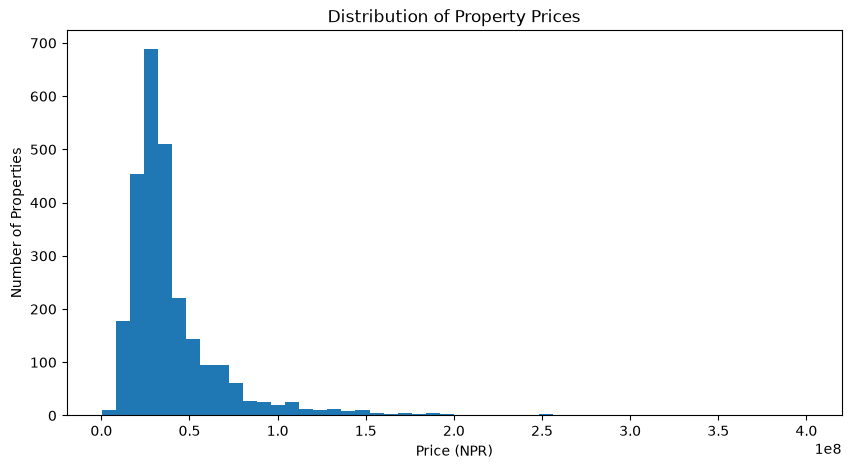

In [260]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(df_model["PRICE_NUM"], bins=50)
plt.xlabel("Price (NPR)")
plt.ylabel("Number of Properties")
plt.title("Distribution of Property Prices")
plt.show()

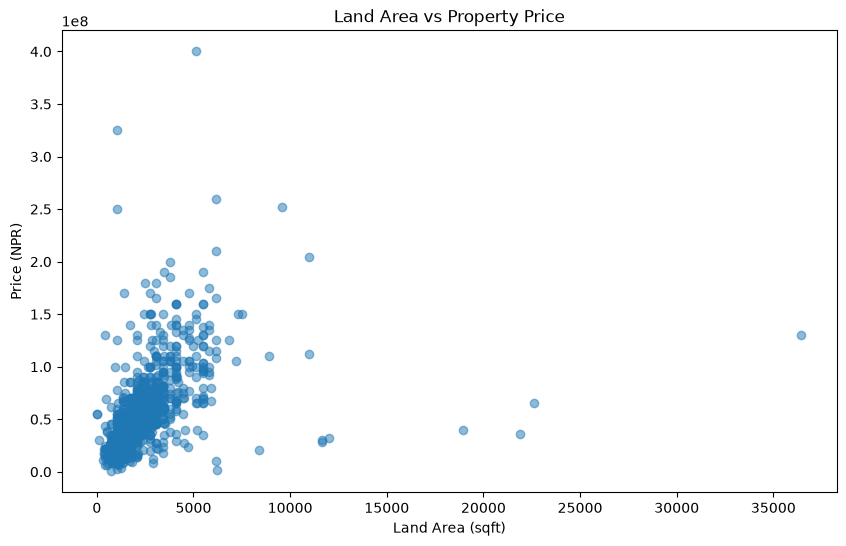

In [261]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df_model["LAND_AREA_SQFT"],
    df_model["PRICE_NUM"],
    alpha=0.5
)

plt.xlabel("Land Area (sqft)")
plt.ylabel("Price (NPR)")
plt.title("Land Area vs Property Price")
plt.show()

In [262]:
df_model[[
    "LAND_AREA_SQFT",
    "PRICE_NUM"
]].corr()

,LAND_AREA_SQFT,PRICE_NUM
LAND_AREA_SQFT,1.00000,0.53622
PRICE_NUM,0.53622,1.00000


In [263]:
df_model[[
    "BEDROOM",
    "PRICE_NUM"
]].corr()

,BEDROOM,PRICE_NUM
BEDROOM,1.000000,0.196318
PRICE_NUM,0.196318,1.000000


In [264]:
df_model[[
    "BATHROOM",
    "PRICE_NUM"
]].corr()

,BATHROOM,PRICE_NUM
BATHROOM,1.00000,0.30527
PRICE_NUM,0.30527,1.00000


In [265]:
df_model[[
    "FLOOR",
    "PRICE_NUM"
]].corr()

,FLOOR,PRICE_NUM
FLOOR,1.000000,0.312201
PRICE_NUM,0.312201,1.000000


In [266]:
df_model[[
    "ROAD_ACCESS_FEET",
    "PRICE_NUM"
]].corr()

,ROAD_ACCESS_FEET,PRICE_NUM
ROAD_ACCESS_FEET,1.000000,0.158663
PRICE_NUM,0.158663,1.000000


In [267]:
df_model[[
    "BUILT_YEAR_AD",
    "PRICE_NUM"
]].corr()

,BUILT_YEAR_AD,PRICE_NUM
BUILT_YEAR_AD,1.000000,-0.017058
PRICE_NUM,-0.017058,1.000000


In [268]:
df_model["LOCATION"].value_counts().head(20)

LOCATION
Imadol, Lalitpur             220
Budhanilkantha, Kathmandu    153
Bhaisepati, Lalitpur         141
Dhapasi, Kathmandu            58
Kapan, Kathmandu              49
Sitapaila, Kathmandu          43
Thankot, Kathmandu            43
Bhangal , Kathmandu           40
Hattiban, Lalitpur            39
Pasikot, Kathmandu            34
Tikathali, Lalitpur           33
Mandikhatar, Kathmandu        33
Hattigaunda, Kathmandu        33
 Sitapaila,  Kathmandu        30
Golfutar, Kathmandu           29
Nakhipot, Lalitpur            28
Sukedhara, Kathmandu          24
Bafal, Kathmandu              23
Nakkhu, Lalitpur              23
Syuchatar, Kathmandu          20
Name: count, dtype: int64

In [269]:
df_model["LOCATION"].nunique()

480

In [270]:
df_model["LOCATION"].str.strip().nunique()

473

In [271]:
df_model["LOCATION"] = df_model["LOCATION"].str.strip()

In [272]:
df_model["LOCATION"].nunique()

473

In [273]:
df_model["LOCATION"].value_counts().head(30)

LOCATION
Imadol, Lalitpur             220
Budhanilkantha, Kathmandu    153
Bhaisepati, Lalitpur         141
Dhapasi, Kathmandu            58
Kapan, Kathmandu              49
Sitapaila, Kathmandu          43
Thankot, Kathmandu            43
Bhangal , Kathmandu           40
Hattiban, Lalitpur            39
Pasikot, Kathmandu            34
Tikathali, Lalitpur           33
Mandikhatar, Kathmandu        33
Hattigaunda, Kathmandu        33
Sitapaila,  Kathmandu         33
Golfutar, Kathmandu           29
Nakhipot, Lalitpur            28
Sukedhara, Kathmandu          24
Bafal, Kathmandu              23
Nakkhu, Lalitpur              23
Syuchatar, Kathmandu          20
Khumaltar, Lalitpur           19
Kalanki, Kathmandu            19
Sundarbasti, Kathmandu        19
Hepali Height, Kathmandu      18
Bansbari, Kathmandu           18
Dhapakhel, Lalitpur           17
Narayanthan , Kathmandu       16
Baluwatar, Kathmandu          16
Sanepa, Lalitpur              15
Banasthali, Kathmandu         15
N

In [274]:
df_model["LOCATION"].value_counts().tail(20)

LOCATION
Grande,  Kathmandu              1
Jharuwarasi,  Lalitpur          1
Ichangunarayan,  Kathmandu      1
Tarkeshwor,  Kathmandu          1
Banasthali,  Kathmandu          1
Nepaltar,  Kathmandu            1
Dahachowk,  Kathmandu           1
Kusunti,  Lalitpur              1
Mahankal ,  Kathmandu           1
Budhanikantha,  Kathmandu       1
Budhanilkantha,  Narayanthan    1
Boudha,  Kathmandu              1
Dhapasi,  Kathmandu             1
Chauni,  Kathmandu              1
Tarkeshwor,  Kathmandhu         1
Dhungedhara,  Kathmandu         1
BUDDHA CHOWK,  KATHMANDU        1
Kapan,  Kathmandu               1
Kalanki,  Kathmandu             1
Sitapiala,  Kathmandu           1
Name: count, dtype: int64

In [275]:
df_model["LOCATION"] = (
    df_model["LOCATION"]
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
    .str.replace(r"\s*,\s*", ", ", regex=True)
    .str.title()
)

In [276]:
df_model["LOCATION"].nunique()

415

In [277]:
df_model["LOCATION"].value_counts().head(20)

LOCATION
Imadol, Lalitpur             225
Budhanilkantha, Kathmandu    163
Bhaisepati, Lalitpur         145
Sitapaila, Kathmandu          77
Dhapasi, Kathmandu            59
Kapan, Kathmandu              50
Thankot, Kathmandu            49
Hattiban, Lalitpur            42
Bhangal, Kathmandu            40
Pasikot, Kathmandu            34
Tikathali, Lalitpur           33
Mandikhatar, Kathmandu        33
Hattigaunda, Kathmandu        33
Bafal, Kathmandu              31
Golfutar, Kathmandu           30
Nakhipot, Lalitpur            29
Sukedhara, Kathmandu          24
Syuchatar, Kathmandu          24
Nakkhu, Lalitpur              23
Khumaltar, Lalitpur           21
Name: count, dtype: int64

In [278]:
df_model[
    df_model["LOCATION"].str.contains(
        "Budhani|Sitap|Kathmandhu|Buddha",
        case=False,
        na=False
    )
]["LOCATION"].value_counts()

LOCATION
Budhanilkantha, Kathmandu      163
Sitapaila, Kathmandu            77
Buddha Chowk, Kathmandu          3
Buddha Colony, Kathmandu         1
Civil Home, Sitapaila            1
Budhanilkanta, Kathmandu         1
Sitapaila-5, Kathmandu           1
Budhanikantha, Kathmandu         1
Budhanilkantha, Narayanthan      1
Tarkeshwor, Kathmandhu           1
Sitapiala, Kathmandu             1
Name: count, dtype: int64

In [279]:
df_model["LOCATION"] = df_model["LOCATION"].replace({
    "Budhanilkanta, Kathmandu": "Budhanilkantha, Kathmandu",
    "Budhanikantha, Kathmandu": "Budhanilkantha, Kathmandu",
    "Sitapiala, Kathmandu": "Sitapaila, Kathmandu",
    "Tarkeshwor, Kathmandhu": "Tarkeshwor, Kathmandu"
})

In [280]:
df_model["LOCATION"].nunique()

411

In [281]:
df_model["LOCATION"].value_counts().head(20)

LOCATION
Imadol, Lalitpur             225
Budhanilkantha, Kathmandu    165
Bhaisepati, Lalitpur         145
Sitapaila, Kathmandu          78
Dhapasi, Kathmandu            59
Kapan, Kathmandu              50
Thankot, Kathmandu            49
Hattiban, Lalitpur            42
Bhangal, Kathmandu            40
Pasikot, Kathmandu            34
Tikathali, Lalitpur           33
Mandikhatar, Kathmandu        33
Hattigaunda, Kathmandu        33
Bafal, Kathmandu              31
Golfutar, Kathmandu           30
Nakhipot, Lalitpur            29
Sukedhara, Kathmandu          24
Syuchatar, Kathmandu          24
Nakkhu, Lalitpur              23
Khumaltar, Lalitpur           21
Name: count, dtype: int64

In [282]:
df_model["LOCATION"] = df_model["LOCATION"].replace({
    "Budhanilkanta, Kathmandu": "Budhanilkantha, Kathmandu",
    "Budhanikantha, Kathmandu": "Budhanilkantha, Kathmandu",
    "Sitapiala, Kathmandu": "Sitapaila, Kathmandu",
    "Tarkeshwor, Kathmandhu": "Tarkeshwor, Kathmandu"
})

In [283]:
df_model.head()


,TITLE,LOCATION,PRICE,FLOOR,BEDROOM,BATHROOM,AMENITIES,PRICE_NUM,LAND_AREA_SQFT,ROAD_ACCESS_FEET,BUILT_YEAR_AD,FACING_CLEAN,BUILDUP_AREA_SQFT,PARKING_CARS,PARKING_BIKES,BUILDUP_AREA_MISSING
0,House for Sale,"Imadol, Lalitpur",Rs. 2.9 Cr,3.0,5.0,4.0,"['Earthquake Resistant', 'Marbel', 'Parquet', ...",29000000.0,1369.000,12.0,2019.0,West,NaN,1.0,2.0,1
1,House for Sale,"Satdobato, Lalitpur",Rs. 4.75 Cr,4.5,5.0,6.0,"['Earthquake Resistant', 'Parquet', 'Drinking ...",47500000.0,1026.750,10.0,2019.0,West,NaN,2.0,2.0,1
2,4 BHK House for Sale,"Imadol, Lalitpur",Rs. 1.99 Cr,2.5,4.0,4.0,"['Earthquake Resistant', 'Marbel', 'Parquet', ...",19900000.0,787.175,10.0,2003.0,West,NaN,1.0,3.0,1
3,Bungalow House for Sale,"Bhaisepati, Lalitpur",Rs. 4 Cr,2.5,4.0,3.0,"['Earthquake Resistant', 'Marbel', 'Parquet', ...",40000000.0,2395.750,12.0,2002.0,North-West,NaN,4.0,4.0,1
6,3 BHK House for Sale,"Bhaisepati, Lalitpur",Rs. 3.3 Cr,2.5,4.0,3.0,"['Earthquake Resistant', 'Marbel', 'Parquet', ...",33000000.0,1095.200,13.0,2017.0,North-West,NaN,4.0,5.0,1


In [284]:
df_model.shape


(2633, 16)

In [285]:
df_model.info()

<class 'pandas.DataFrame'>
Index: 2633 entries, 0 to 3416
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   TITLE                 2633 non-null   str    
 1   LOCATION              2633 non-null   str    
 2   PRICE                 2633 non-null   str    
 3   FLOOR                 2583 non-null   float64
 4   BEDROOM               2435 non-null   float64
 5   BATHROOM              2378 non-null   float64
 6   AMENITIES             2633 non-null   str    
 7   PRICE_NUM             2633 non-null   float64
 8   LAND_AREA_SQFT        2612 non-null   float64
 9   ROAD_ACCESS_FEET      2631 non-null   float64
 10  BUILT_YEAR_AD         2608 non-null   float64
 11  FACING_CLEAN          2568 non-null   str    
 12  BUILDUP_AREA_SQFT     527 non-null    float64
 13  PARKING_CARS          477 non-null    float64
 14  PARKING_BIKES         499 non-null    float64
 15  BUILDUP_AREA_MISSING  2633 non-null  

In [286]:
df_model["LOCATION"].isin([
    "Budhanilkanta, Kathmandu",
    "Budhanikantha, Kathmandu",
    "Sitapiala, Kathmandu",
    "Tarkeshwor, Kathmandhu"
]).sum()

np.int64(0)

In [287]:
X = df_model.drop(columns=[
    "PRICE",
    "PRICE_NUM",
    "TITLE",
    "AMENITIES"
])
y = df_model["PRICE_NUM"]

In [288]:
print(X.shape)
print(y.shape)

print(X.head())
print(y.head())

(2633, 12)
(2633,)
               LOCATION  FLOOR  BEDROOM  BATHROOM  LAND_AREA_SQFT  \
0      Imadol, Lalitpur    3.0      5.0       4.0        1369.000   
1   Satdobato, Lalitpur    4.5      5.0       6.0        1026.750   
2      Imadol, Lalitpur    2.5      4.0       4.0         787.175   
3  Bhaisepati, Lalitpur    2.5      4.0       3.0        2395.750   
6  Bhaisepati, Lalitpur    2.5      4.0       3.0        1095.200   

   ROAD_ACCESS_FEET  BUILT_YEAR_AD FACING_CLEAN  BUILDUP_AREA_SQFT  \
0              12.0         2019.0         West                NaN   
1              10.0         2019.0         West                NaN   
2              10.0         2003.0         West                NaN   
3              12.0         2002.0   North-West                NaN   
6              13.0         2017.0   North-West                NaN   

   PARKING_CARS  PARKING_BIKES  BUILDUP_AREA_MISSING  
0           1.0            2.0                     1  
1           2.0            2.0     

In [289]:
from sklearn.model_selection import train_test_split

In [290]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [291]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (2106, 12)
X_test : (527, 12)
y_train: (2106,)
y_test : (527,)


In [292]:
numeric_features = [
    "FLOOR",
    "BEDROOM",
    "BATHROOM",
    "LAND_AREA_SQFT",
    "ROAD_ACCESS_FEET",
    "BUILT_YEAR_AD",
    "BUILDUP_AREA_SQFT",
    "PARKING_CARS",
    "PARKING_BIKES",
    "BUILDUP_AREA_MISSING"
]

In [293]:
categorical_features = [
    "LOCATION",
    "FACING_CLEAN"
]

In [294]:
print(X[numeric_features].dtypes)
print(X[categorical_features].dtypes)

FLOOR                   float64
BEDROOM                 float64
BATHROOM                float64
LAND_AREA_SQFT          float64
ROAD_ACCESS_FEET        float64
BUILT_YEAR_AD           float64
BUILDUP_AREA_SQFT       float64
PARKING_CARS            float64
PARKING_BIKES           float64
BUILDUP_AREA_MISSING      int64
dtype: object
LOCATION        str
FACING_CLEAN    str
dtype: object


In [295]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [296]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

In [297]:
categorical_features = [
    "LOCATION",
    "FACING_CLEAN"
]

In [298]:
from sklearn.preprocessing import OneHotEncoder


In [299]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [300]:
from sklearn.compose import ColumnTransformer

In [301]:
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

In [302]:
from sklearn.ensemble import RandomForestRegressor

model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

In [303]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['LOCATION','FLOOR','BEDROOM',...,'PARKING_CARS','PARKING_BIKES', 'BUILDUP_AREA_MISSING']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. 

In [304]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[59067500.         17991000.         42165833.33333333 24204500.
 23720000.         22784000.         28642500.         37769000.
 32666000.         86657000.        ]


In [305]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [306]:
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 10566019.244149271
RMSE: 22177859.219256185
R²  : 0.50354699313754


In [307]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison["Error"] = comparison["Actual"] - comparison["Predicted"]

comparison.head(10)

,Actual,Predicted,Error
0,45000000.0,5.906750e+07,-1.406750e+07
1,14300000.0,1.799100e+07,-3.691000e+06
2,34500000.0,4.216583e+07,-7.665833e+06
3,17500000.0,2.420450e+07,-6.704500e+06
4,20500000.0,2.372000e+07,-3.220000e+06
5,18500000.0,2.278400e+07,-4.284000e+06
6,23000000.0,2.864250e+07,-5.642500e+06
7,59000000.0,3.776900e+07,2.123100e+07
8,55000000.0,3.266600e+07,2.233400e+07
9,252000000.0,8.665700e+07,1.653430e+08


In [308]:
y.describe()

count    2.633000e+03
mean     4.000547e+07
std      2.866732e+07
min      2.680000e+05
25%      2.450000e+07
50%      3.200000e+07
75%      4.500000e+07
max      4.000000e+08
Name: PRICE_NUM, dtype: float64

In [309]:
print("Maximum price:", y.max())
print("90th percentile:", y.quantile(0.90))
print("95th percentile:", y.quantile(0.95))
print("99th percentile:", y.quantile(0.99))

Maximum price: 400000000.0
90th percentile: 70000000.0
95th percentile: 95000000.0
99th percentile: 150000000.0


In [310]:
from sklearn.linear_model import LinearRegression

linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

In [311]:
linear_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['LOCATION','FLOOR','BEDROOM',...,'PARKING_CARS','PARKING_BIKES', 'BUILDUP_AREA_MISSING']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. 

In [312]:
y_pred_linear = linear_model.predict(X_test)

In [313]:
mae_linear = mean_absolute_error(y_test, y_pred_linear)
rmse_linear = mean_squared_error(y_test, y_pred_linear) ** 0.5
r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression")
print("MAE :", mae_linear)
print("RMSE:", rmse_linear)
print("R²  :", r2_linear)

Linear Regression
MAE : 12803225.126448777
RMSE: 23452607.930857353
R²  : 0.4448361391627196


In [314]:
import numpy as np

y_log = np.log1p(y)

In [315]:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

In [316]:
log_rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

In [317]:
log_rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

In [318]:
log_rf_model.fit(X_train, y_train_log)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['LOCATION','FLOOR','BEDROOM',...,'PARKING_CARS','PARKING_BIKES', 'BUILDUP_AREA_MISSING']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. 

In [319]:
y_pred_log = log_rf_model.predict(X_test)

In [320]:
y_pred_log_original = np.expm1(y_pred_log)

In [321]:
mae_log = mean_absolute_error(y_test, y_pred_log_original)
rmse_log = mean_squared_error(y_test, y_pred_log_original) ** 0.5
r2_log = r2_score(y_test, y_pred_log_original)

print("Log Random Forest")
print("MAE :", mae_log)
print("RMSE:", rmse_log)
print("R²  :", r2_log)

Log Random Forest
MAE : 10468798.52034845
RMSE: 21821851.252399176
R²  : 0.519357596231218


In [322]:
feature_names = log_rf_model.named_steps["preprocessor"].get_feature_names_out()

importances = log_rf_model.named_steps["regressor"].feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

feature_importance.head(20)

,Feature,Importance
3,num__LAND_AREA_SQFT,0.566854
0,num__FLOOR,0.074257
2,num__BATHROOM,0.040033
4,num__ROAD_ACCESS_FEET,0.033520
5,num__BUILT_YEAR_AD,0.027954
159,"cat__LOCATION_Janakpur, Dhanusa",0.022745
1,num__BEDROOM,0.019810
359,"cat__LOCATION_Thankot, Kathmandu",0.019303
6,num__BUILDUP_AREA_SQFT,0.018127
43,"cat__LOCATION_Bhaisepati, Lalitpur",0.007787


In [323]:
df_model[[
    "PRICE_NUM",
    "LAND_AREA_SQFT",
    "BUILDUP_AREA_SQFT",
    "BEDROOM",
    "BATHROOM",
    "ROAD_ACCESS_FEET",
    "BUILT_YEAR_AD",
    "FLOOR",
    "PARKING_CARS",
    "PARKING_BIKES"
]].corr()["PRICE_NUM"].sort_values(ascending=False)

PRICE_NUM            1.000000
LAND_AREA_SQFT       0.536220
PARKING_CARS         0.388758
PARKING_BIKES        0.334077
FLOOR                0.312201
BATHROOM             0.305270
BEDROOM              0.196318
BUILDUP_AREA_SQFT    0.185462
ROAD_ACCESS_FEET     0.158663
BUILT_YEAR_AD       -0.017058
Name: PRICE_NUM, dtype: float64

In [324]:
df_model["LAND_AREA_SQFT"].describe()

count     2612.000000
mean      1741.764231
std       1430.011305
min          0.000000
25%       1095.200000
50%       1369.000000
75%       1779.700000
max      36450.000000
Name: LAND_AREA_SQFT, dtype: float64

In [325]:
df_model["LAND_AREA_SQFT"].isna().sum()

np.int64(21)

In [326]:
df_model["LAND_AREA_SQFT"].sort_values(ascending=False).head(20)

1376    36450.000
2089    22599.000
3050    21870.000
1880    18954.000
2068    12028.500
713     11664.000
1366    11664.000
3121    10952.000
2411    10952.000
136      9583.000
2924     8898.500
1111     8383.500
3103     7529.500
1692     7289.925
3388     7187.250
3324     6845.000
546      6196.500
1976     6160.500
1263     6160.500
1941     6160.500
Name: LAND_AREA_SQFT, dtype: float64

In [327]:
df_model[df_model["LAND_AREA_SQFT"] == 0][
    ["TITLE", "LOCATION", "PRICE", "LAND_AREA_SQFT"]
]

,TITLE,LOCATION,PRICE,LAND_AREA_SQFT
1528,"Beautiful house for sale Near Kitini School, G...","Godawari, Lalitpur",Rs. 5.5 Cr,0.0


In [328]:
import numpy as np

df_model["LAND_AREA_SQFT"] = df_model["LAND_AREA_SQFT"].replace(0, np.nan)

In [329]:
df_model["LAND_AREA_SQFT"].isna().sum()

np.int64(22)

In [330]:
SimpleImputer(strategy="median")

,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False


In [331]:
Q1 = df_model["LAND_AREA_SQFT"].quantile(0.25)
Q3 = df_model["LAND_AREA_SQFT"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

Q1: 1095.2
Q3: 1779.7
IQR: 684.5
Lower bound: 68.45000000000005
Upper bound: 2806.45


In [332]:
(df_model["LAND_AREA_SQFT"] > 2806.45).sum()

np.int64(265)

In [333]:
df_model[df_model["LAND_AREA_SQFT"] > 2806.45][
    ["LAND_AREA_SQFT", "PRICE_NUM", "LOCATION"]
].sort_values("LAND_AREA_SQFT", ascending=False).head(20)

,LAND_AREA_SQFT,PRICE_NUM,LOCATION
1376,36450.000,130000000.0,"Bishalnagar, Kathmandu"
2089,22599.000,65000000.0,"Baluwatar, Kathmandu"
3050,21870.000,36000000.0,"Kapan, Kathmandu"
1880,18954.000,40000000.0,"Dhapakhel, Lalitpur"
2068,12028.500,32500000.0,"Nakhipot, Lalitpur"
713,11664.000,28000000.0,"Imadol, Lalitpur"
1366,11664.000,30000000.0,"Rai Chowk, Kathmandu"
3121,10952.000,204800000.0,"Baluwatar, Kathmandu"
2411,10952.000,112000000.0,"Raniban, Kathmandu"
136,9583.000,252000000.0,"Baneshwor, Kathmandu"


In [334]:
X = df_model.drop(columns=[
    "PRICE",
    "PRICE_NUM",
    "TITLE",
    "AMENITIES"
])

y = df_model["PRICE_NUM"]

In [335]:
print(X.shape)
print(y.shape)

(2633, 12)
(2633,)


In [336]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [337]:
print(X_train.shape)
print(X_test.shape)

(2106, 12)
(527, 12)


In [338]:
y_train_log = np.log1p(y_train)

log_rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

log_rf_model.fit(X_train, y_train_log)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['LOCATION','FLOOR','BEDROOM',...,'PARKING_CARS','PARKING_BIKES', 'BUILDUP_AREA_MISSING']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. 

In [339]:
y_pred_log = log_rf_model.predict(X_test)

y_pred = np.expm1(y_pred_log)

In [340]:
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print("Log Random Forest (Corrected Land Area)")
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

Log Random Forest (Corrected Land Area)
MAE : 10496774.074419033
RMSE: 21822287.3771708
R²  : 0.5193383840983101


In [351]:
df_model["LOCATION"].nunique()

411

In [352]:
df_model["LOCATION"].value_counts().describe()

count    411.000000
mean       6.406326
std       17.163428
min        1.000000
25%        1.000000
50%        2.000000
75%        6.000000
max      225.000000
Name: count, dtype: float64

In [353]:
location_counts = df_model["LOCATION"].value_counts()

print("Locations with 1 listing:", (location_counts == 1).sum())
print("Locations with <= 2 listings:", (location_counts <= 2).sum())
print("Locations with <= 5 listings:", (location_counts <= 5).sum())

Locations with 1 listing: 154
Locations with <= 2 listings: 231
Locations with <= 5 listings: 303


In [354]:
X_train_location = X_train[["LOCATION"]]

location_encoder = OneHotEncoder(handle_unknown="ignore")

location_encoded = location_encoder.fit_transform(X_train_location)

print("Location categories:", len(location_encoder.categories_[0]))

Location categories: 375


In [355]:
train_location_counts = X_train["LOCATION"].value_counts()

print(train_location_counts.value_counts().sort_index().head(10))

count
1     159
2      58
3      28
4      25
5      14
6      21
7       9
8       8
9       8
10      8
Name: count, dtype: int64


In [356]:
print(train_location_counts.head(15))

LOCATION
Imadol, Lalitpur             183
Budhanilkantha, Kathmandu    143
Bhaisepati, Lalitpur         119
Sitapaila, Kathmandu          55
Dhapasi, Kathmandu            43
Thankot, Kathmandu            40
Kapan, Kathmandu              40
Hattiban, Lalitpur            34
Bhangal, Kathmandu            33
Pasikot, Kathmandu            29
Hattigaunda, Kathmandu        29
Tikathali, Lalitpur           26
Nakhipot, Lalitpur            26
Mandikhatar, Kathmandu        25
Golfutar, Kathmandu           24
Name: count, dtype: int64


In [357]:
from sklearn.model_selection import RandomizedSearchCV

In [358]:
param_dist = {
    "regressor__n_estimators": [100, 200, 300, 500],
    "regressor__max_depth": [None, 5, 10, 15, 20],
    "regressor__min_samples_split": [2, 5, 10],
    "regressor__min_samples_leaf": [1, 2, 4],
    "regressor__max_features": ["sqrt", "log2", 0.5, 1.0]
}

In [360]:
random_search_safe = RandomizedSearchCV(
    estimator=log_rf_model,
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring="neg_mean_absolute_error",
    random_state=42,
    n_jobs=2
)

In [361]:
random_search.fit(X_train, y_train_log)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'regressor__max_depth': [None, 5, ...], 'regressor__max_features': ['sqrt', 'log2', ...], 'regressor__min_samples_leaf': [1, 2, ...], 'regressor__min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits usin

In [362]:
print(random_search.best_params_)

{'regressor__n_estimators': 300, 'regressor__min_samples_split': 2, 'regressor__min_samples_leaf': 2, 'regressor__max_features': 0.5, 'regressor__max_depth': None}


In [365]:
tuned_log_rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=2,
        max_features=0.5,
        random_state=42,
        n_jobs=2
    ))
])

In [366]:
tuned_log_rf_model.fit(X_train, y_train_log)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['LOCATION','FLOOR','BEDROOM',...,'PARKING_CARS','PARKING_BIKES', 'BUILDUP_AREA_MISSING']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. 

In [367]:
y_pred_tuned_log = tuned_log_rf_model.predict(X_test)

y_pred_tuned = np.expm1(y_pred_tuned_log)

In [368]:
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
r2_tuned = r2_score(y_test, y_pred_tuned)



In [369]:
print("Tuned Log Random Forest")
print("MAE :", mae_tuned)
print("RMSE:", rmse_tuned)
print("R²  :", r2_tuned)

Tuned Log Random Forest
MAE : 10647524.077704819
RMSE: 22895738.79268185
R²  : 0.47088725306845824


In [370]:
error_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred,
})

error_df["Error"] = error_df["Actual"] - error_df["Predicted"]
error_df["Absolute_Error"] = abs(error_df["Error"])

error_df.sort_values(
    "Absolute_Error",
    ascending=False
).head(10)

,Actual,Predicted,Error,Absolute_Error
2299,250000000.0,4.364552e+07,2.063545e+08,2.063545e+08
2050,190000000.0,4.070170e+07,1.492983e+08,1.492983e+08
136,252000000.0,1.074569e+08,1.445431e+08,1.445431e+08
2947,260000000.0,1.219216e+08,1.380784e+08,1.380784e+08
273,180000000.0,6.281668e+07,1.171833e+08,1.171833e+08
1111,21000000.0,1.316883e+08,-1.106883e+08,1.106883e+08
1455,125000000.0,2.087077e+07,1.041292e+08,1.041292e+08
1271,190000000.0,8.716250e+07,1.028375e+08,1.028375e+08
1081,100000000.0,1.381399e+07,8.618601e+07,8.618601e+07
166,27720000.0,1.063813e+08,-7.866130e+07,7.866130e+07


In [371]:
error_details = X_test.loc[error_df.index].copy()

error_details["Actual"] = error_df["Actual"]
error_details["Predicted"] = error_df["Predicted"]
error_details["Absolute_Error"] = error_df["Absolute_Error"]

error_details.sort_values(
    "Absolute_Error",
    ascending=False
).head(10)

,LOCATION,FLOOR,BEDROOM,BATHROOM,LAND_AREA_SQFT,ROAD_ACCESS_FEET,BUILT_YEAR_AD,FACING_CLEAN,BUILDUP_AREA_SQFT,PARKING_CARS,PARKING_BIKES,BUILDUP_AREA_MISSING,Actual,Predicted,Absolute_Error
2299,"New Road, Kathmandu",6.0,NaN,NaN,1060.975,18.0000,2021.0,North-East,NaN,NaN,NaN,1,250000000.0,4.364552e+07,2.063545e+08
2050,"Maharajgunj, Kathmandu",6.0,NaN,NaN,NaN,18.0000,2007.0,South-West,NaN,NaN,NaN,1,190000000.0,4.070170e+07,1.492983e+08
136,"Baneshwor, Kathmandu",3.5,NaN,NaN,9583.000,20.0000,2015.0,West,NaN,3.0,5.0,1,252000000.0,1.074569e+08,1.445431e+08
2947,"Balaju, Kathmandu",5.0,10.0,6.0,6160.500,15.0000,2013.0,North,NaN,NaN,NaN,1,260000000.0,1.219216e+08,1.380784e+08
273,"Kamalpokhari, Kathmandu",5.0,12.0,6.0,2498.425,65.6168,2022.0,North,NaN,NaN,NaN,1,180000000.0,6.281668e+07,1.171833e+08
1111,"Imadol, Lalitpur",2.5,4.0,4.0,8383.500,13.0000,2008.0,North,NaN,NaN,NaN,1,21000000.0,1.316883e+08,1.106883e+08
1455,"Dhapasi, Kathmandu",2.0,5.0,5.0,1026.750,18.0000,2016.0,South-East,NaN,NaN,NaN,1,125000000.0,2.087077e+07,1.041292e+08
1271,"Sanepa, Lalitpur",3.0,5.0,5.0,5476.000,18.0000,2013.0,West,2383.00,NaN,NaN,0,190000000.0,8.716250e+07,1.028375e+08
1081,"Gagangauda, Kaski",1.0,2.0,2.0,936.000,20.0000,2008.0,North,936.00,NaN,NaN,0,100000000.0,1.381399e+07,8.618601e+07
166,"Bauthali, Kathmandu",3.0,10.0,8.0,4517.700,20.0000,2001.0,North-East,2368.08,5.0,9.0,0,27720000.0,1.063813e+08,7.866130e+07


In [372]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Log Random Forest",
        "Tuned Log Random Forest"
    ],
    "MAE": [
        12803225.13,
        10566019.24,
        10496774.07,
        10647524.08
    ],
    "RMSE": [
        23452607.93,
        22177859.22,
        21822287.38,
        22895738.79
    ],
    "R2": [
        0.444836,
        0.503547,
        0.519338,
        0.470887
    ]
})

comparison

,Model,MAE,RMSE,R2
0,Linear Regression,12803225.13,23452607.93,0.444836
1,Random Forest,10566019.24,22177859.22,0.503547
2,Log Random Forest,10496774.07,21822287.38,0.519338
3,Tuned Log Random Forest,10647524.08,22895738.79,0.470887


In [373]:
comparison.sort_values("R2", ascending=False)

,Model,MAE,RMSE,R2
2,Log Random Forest,10496774.07,21822287.38,0.519338
1,Random Forest,10566019.24,22177859.22,0.503547
3,Tuned Log Random Forest,10647524.08,22895738.79,0.470887
0,Linear Regression,12803225.13,23452607.93,0.444836


In [374]:
import joblib

joblib.dump(log_rf_model, "ktm_homevalue_log_random_forest.pkl")

['ktm_homevalue_log_random_forest.pkl']

In [375]:
loaded_model = joblib.load("ktm_homevalue_log_random_forest.pkl")

sample_prediction = loaded_model.predict(X_test.iloc[[0]])
sample_price = np.expm1(sample_prediction)[0]

print(f"Predicted Price: Rs. {sample_price:,.0f}")

Predicted Price: Rs. 58,382,201
